In [34]:
from pathlib import Path
import os

NOTEBOOK_DIR = Path(os.path.abspath(''))
OUTPUT_DIR   = (NOTEBOOK_DIR / '../../../../../output_data').resolve()

esekf_results = {
    # 'walk_2m_01': 'walk_2m_01_esekf.csv',
    'walk_obs_maha': 'walk_obs_maha_esekf.csv',
    'walk_obs_no_maha': 'walk_obs_no_maha_esekf.csv',
}

DT                = 0.001   # 1 kHz
GT_VEL_LPF_CUTOFF = 10.0    # Hz  (must match offline_test)

# ── Mahalanobis threshold (χ²(3, p=0.999) = 16.27) ───────────────────────────
# Set to 1e30 to disable gating (walk_obs_no_maha equivalent)
MAHA_THRESH = 16.27

# ── Plot visibility toggles ───────────────────────────────────────────────────
# Set False to hide a method from plots. RMSE is always computed for all methods.
PLOT_METHODS = {
    'gt':  True,   # Ground Truth
    'imu': True,   # IMU gyro-integrated
    'leg': True,   # Leg odometry
    'est': True,   # ESEKF estimate
}

print(f'OUTPUT_DIR = {OUTPUT_DIR}')
for name, fname in esekf_results.items():
    p = OUTPUT_DIR / fname
    print(f'  [{name}]  {fname}  —  {"FOUND ✓" if p.exists() else "NOT FOUND ✗"}')
print(f'\nMAHA_THRESH = {MAHA_THRESH}')
print(f'PLOT_METHODS = {PLOT_METHODS}')


OUTPUT_DIR = /home/hiho817/corgi_ws/corgi_ros2_ws/output_data
  [walk_obs_maha]  walk_obs_maha_esekf.csv  —  FOUND ✓
  [walk_obs_no_maha]  walk_obs_no_maha_esekf.csv  —  FOUND ✓

MAHA_THRESH = 16.27
PLOT_METHODS = {'gt': True, 'imu': True, 'leg': True, 'est': True}


In [35]:
import numpy as np
import pandas as pd

# ── Pure-numpy helpers (no scipy — binary incompatibility on this system) ──────

def quat_to_rotmat(qw, qx, qy, qz):
    """Convert quaternion arrays (N,) → rotation matrices (N,3,3)."""
    qw, qx, qy, qz = (np.asarray(a, dtype=float) for a in (qw, qx, qy, qz))
    N = qw.shape[0]
    R = np.zeros((N, 3, 3))
    R[:, 0, 0] = 1 - 2*(qy**2 + qz**2)
    R[:, 0, 1] = 2*(qx*qy - qz*qw)
    R[:, 0, 2] = 2*(qx*qz + qy*qw)
    R[:, 1, 0] = 2*(qx*qy + qz*qw)
    R[:, 1, 1] = 1 - 2*(qx**2 + qz**2)
    R[:, 1, 2] = 2*(qy*qz - qx*qw)
    R[:, 2, 0] = 2*(qx*qz - qy*qw)
    R[:, 2, 1] = 2*(qy*qz + qx*qw)
    R[:, 2, 2] = 1 - 2*(qx**2 + qy**2)
    return R

def quat_to_euler_xyz(qw, qx, qy, qz):
    """XYZ extrinsic Euler angles (roll/pitch/yaw) in degrees, shape (N,3)."""
    R = quat_to_rotmat(qw, qx, qy, qz)
    pitch = np.arctan2(-R[:, 2, 0], np.sqrt(R[:, 2, 1]**2 + R[:, 2, 2]**2))
    cp    = np.where(np.abs(np.cos(pitch)) < 1e-6, 1e-6, np.cos(pitch))
    roll  = np.arctan2(R[:, 2, 1] / cp, R[:, 2, 2] / cp)
    yaw   = np.arctan2(R[:, 1, 0] / cp, R[:, 0, 0] / cp)
    return np.degrees(np.stack([roll, pitch, yaw], axis=1))

def central_diff_velocity(pos, dt):
    """Boundary-aware central-difference velocity."""
    vel = np.empty_like(pos)
    vel[1:-1] = (pos[2:] - pos[:-2]) / (2 * dt)
    vel[0]    = (pos[1]  - pos[0])   / dt
    vel[-1]   = (pos[-1] - pos[-2])  / dt
    return vel

def iir_lpf_forward(sig, cutoff_hz, dt):
    """1st-order IIR low-pass (forward pass only, matches offline_test C++ impl)."""
    rc    = 1.0 / (2 * np.pi * cutoff_hz)
    alpha = dt / (rc + dt)
    out   = np.empty_like(sig)
    out[0] = sig[0]
    for i in range(1, len(sig)):
        out[i] = alpha * sig[i] + (1 - alpha) * out[i - 1]
    return out

# ── Load & process each dataset ───────────────────────────────────────────────
datasets = {}

for name, fname in esekf_results.items():
    df = pd.read_csv(OUTPUT_DIR / fname)
    N  = len(df)
    t  = df['Index'].values * DT

    # Ground-truth position (origin-zeroed)
    gt_pos = df[['sim_pos_x', 'sim_pos_y', 'sim_pos_z']].values.copy()
    gt_pos -= gt_pos[0]

    # Rotation matrices
    R_gt  = quat_to_rotmat(df['gt_qw'].values,  df['gt_qx'].values,
                            df['gt_qy'].values,  df['gt_qz'].values)
    R_est = quat_to_rotmat(df['est_qw'].values, df['est_qx'].values,
                            df['est_qy'].values, df['est_qz'].values)

    # GT velocity (world-frame, filtered central diff → body-frame)
    gt_vel_w_raw = central_diff_velocity(gt_pos, DT)
    gt_vel_w     = np.stack([iir_lpf_forward(gt_vel_w_raw[:, i], GT_VEL_LPF_CUTOFF, DT)
                             for i in range(3)], axis=1)
    gt_vel_b     = np.einsum('nij,nj->ni', R_gt.transpose(0, 2, 1), gt_vel_w)

    # IMU gyro-integrated
    imu_pos   = df[['imu_gyro_pos_x', 'imu_gyro_pos_y', 'imu_gyro_pos_z']].values.copy()
    imu_pos  -= imu_pos[0]
    imu_vel_b = df[['imu_gyro_vel_bx', 'imu_gyro_vel_by', 'imu_gyro_vel_bz']].values

    # Leg odometry (integrate R_est @ z_avg * dt)
    z_avg     = df[['z_avg_x', 'z_avg_y', 'z_avg_z']].values
    leg_vel_b = z_avg.copy()
    leg_vel_w = np.einsum('nij,nj->ni', R_est, z_avg)
    leg_pos   = np.zeros((N, 3))
    for i in range(1, N):
        leg_pos[i] = leg_pos[i-1] + leg_vel_w[i] * DT

    # ESEKF estimate
    est_pos   = df[['est_pos_x', 'est_pos_y', 'est_pos_z']].values.copy()
    est_pos  -= est_pos[0]
    est_vel_b = df[['est_vel_x', 'est_vel_y', 'est_vel_z']].values

    # Contacts
    contacts    = df[['contact_a', 'contact_b', 'contact_c', 'contact_d']].values
    any_contact = contacts.any(axis=1)

    datasets[name] = dict(
        df=df, t=t,
        gt_pos=gt_pos, gt_vel_b=gt_vel_b, gt_vel_w=gt_vel_w,
        imu_pos=imu_pos, imu_vel_b=imu_vel_b,
        leg_pos=leg_pos, leg_vel_b=leg_vel_b,
        est_pos=est_pos, est_vel_b=est_vel_b,
        R_gt=R_gt, R_est=R_est,
        contacts=contacts, any_contact=any_contact,
    )
    print(f'[{name}]  N={N}  t={t[-1]:.2f}s  loaded ✓')

print(f'\nTotal datasets: {len(datasets)}')

[walk_obs_maha]  N=12000  t=12.00s  loaded ✓
[walk_obs_no_maha]  N=12000  t=12.00s  loaded ✓

Total datasets: 2


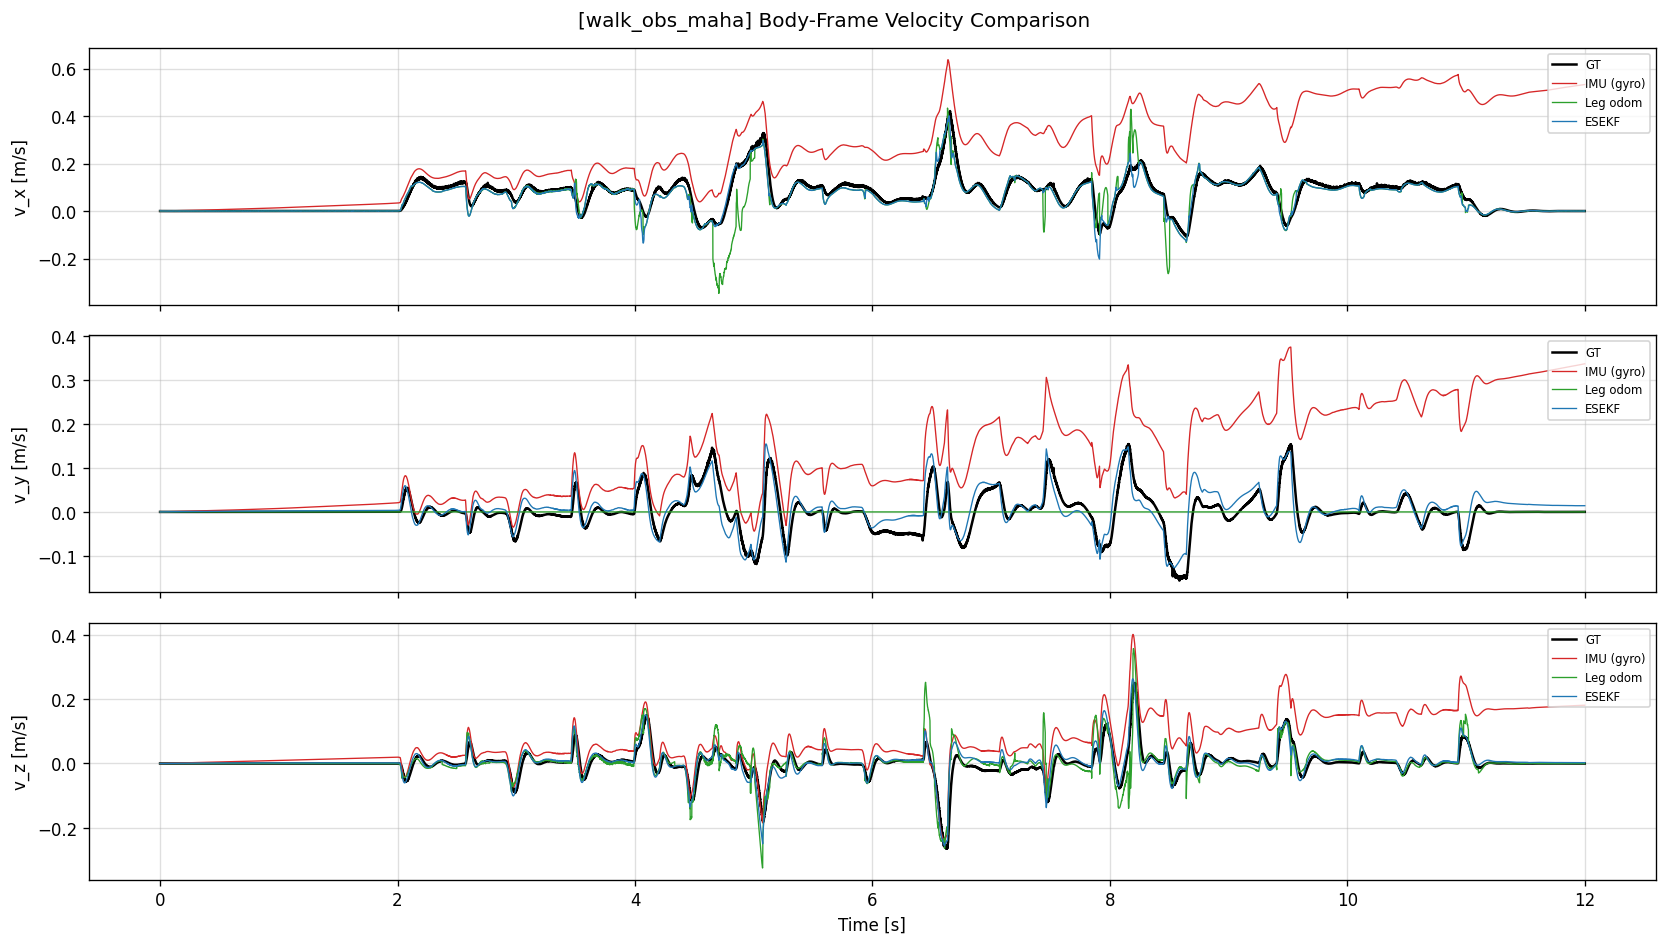

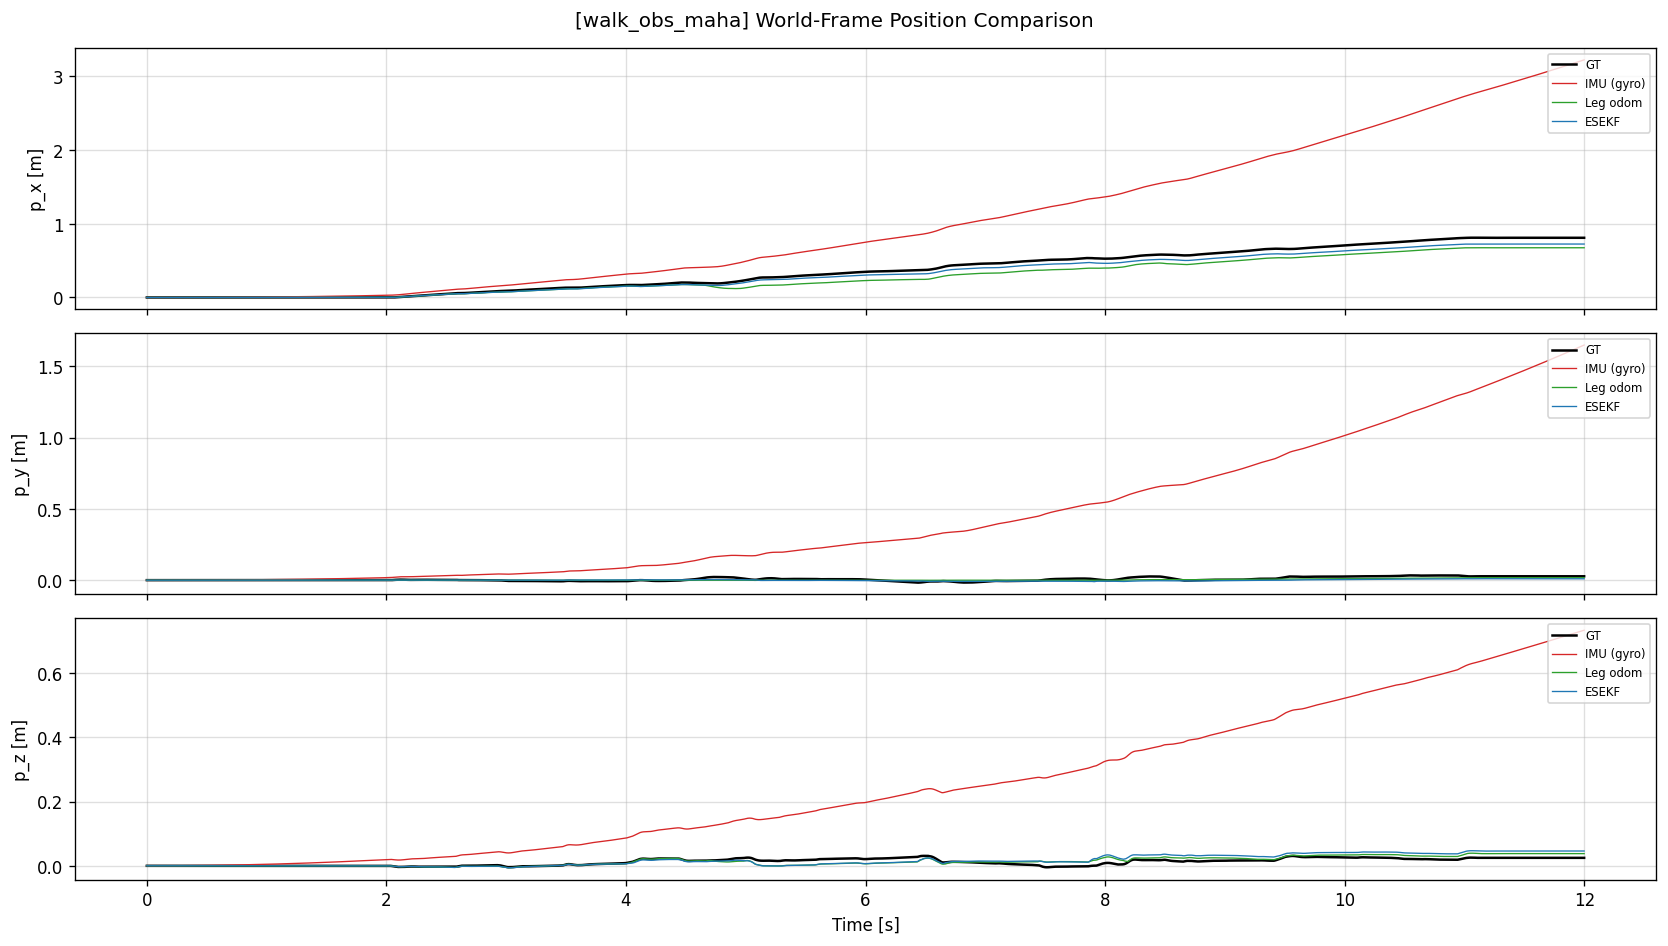

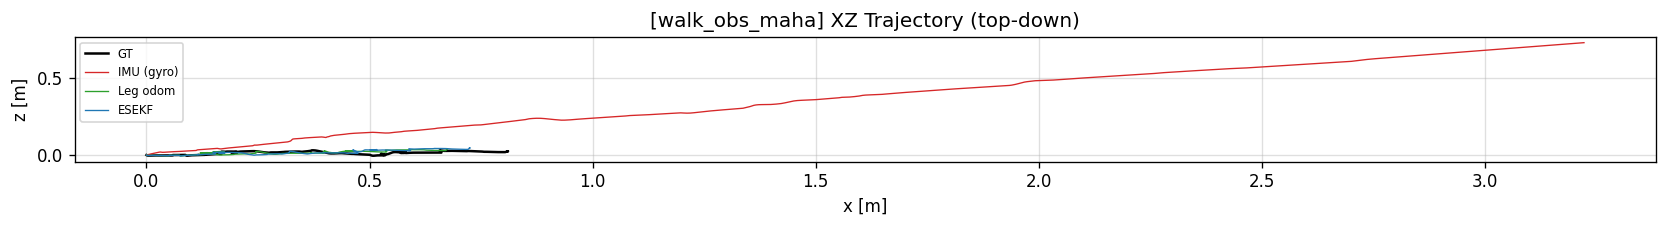


===== [walk_obs_maha] Velocity RMSE vs GT (mm/s) =====
Method                      Vx      Vy      Vz
IMU (gyro)               258.1   160.1    89.9
Leg odom                  47.6    41.8    27.3
ESEKF                     20.9    23.9    18.3

===== [walk_obs_maha] Position RMSE vs GT (mm) =====
Method                      Px      Py      Pz
IMU (gyro)               966.9   641.3   317.9
Leg odom                  97.0     9.4     8.7
ESEKF                     50.8    12.5    12.2


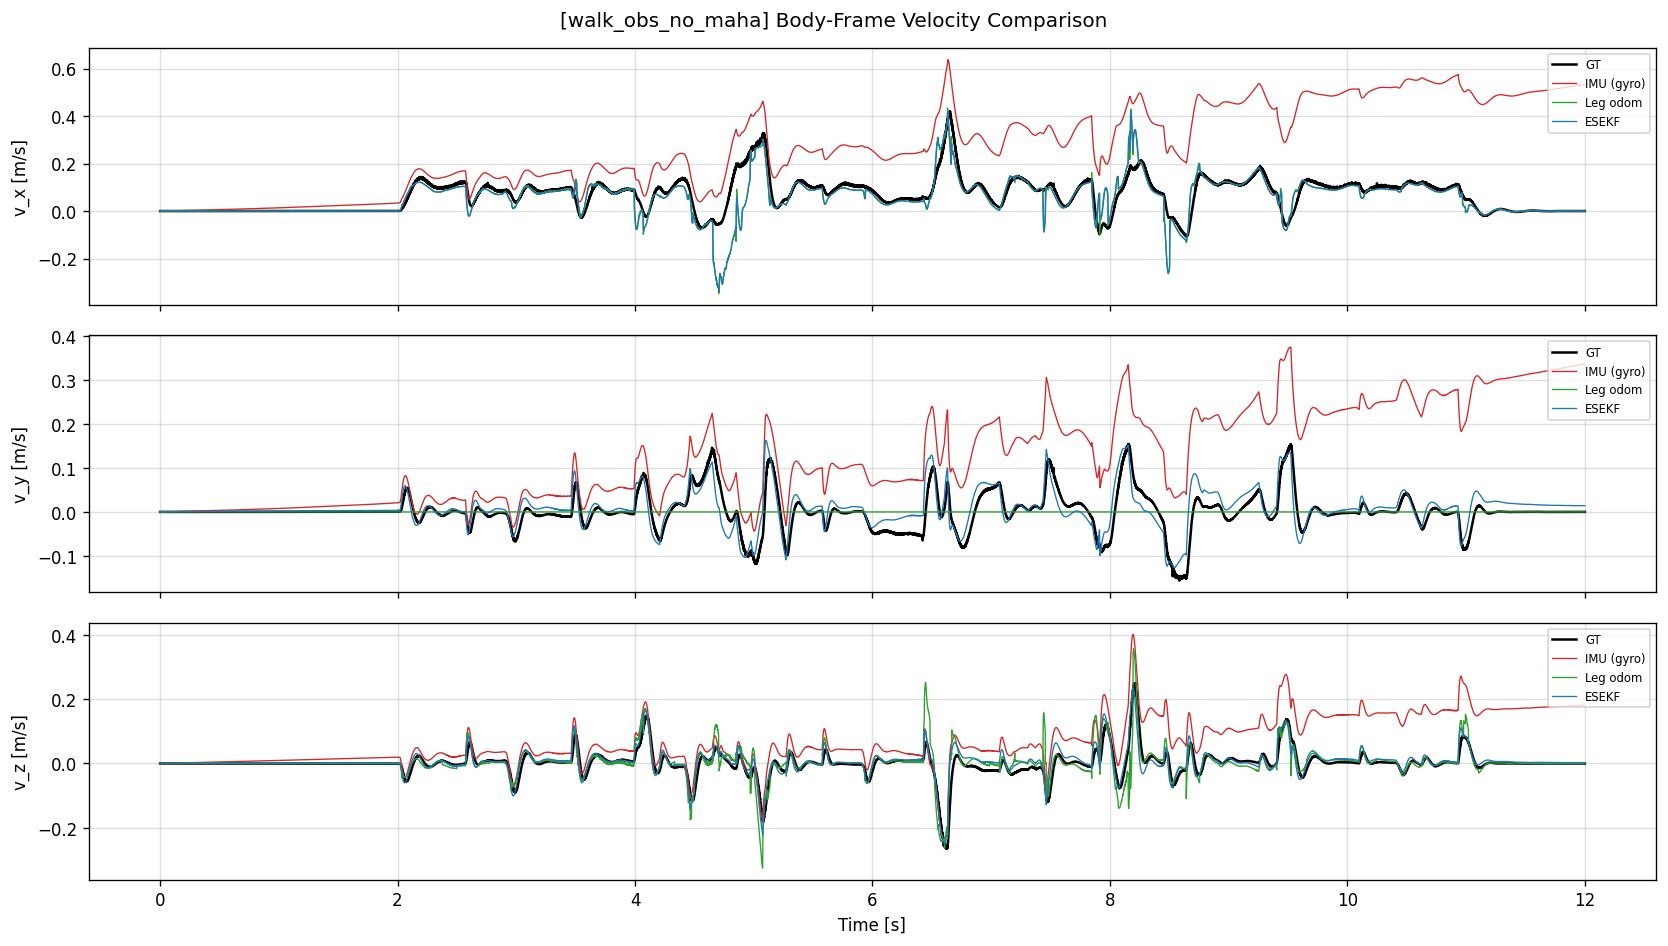

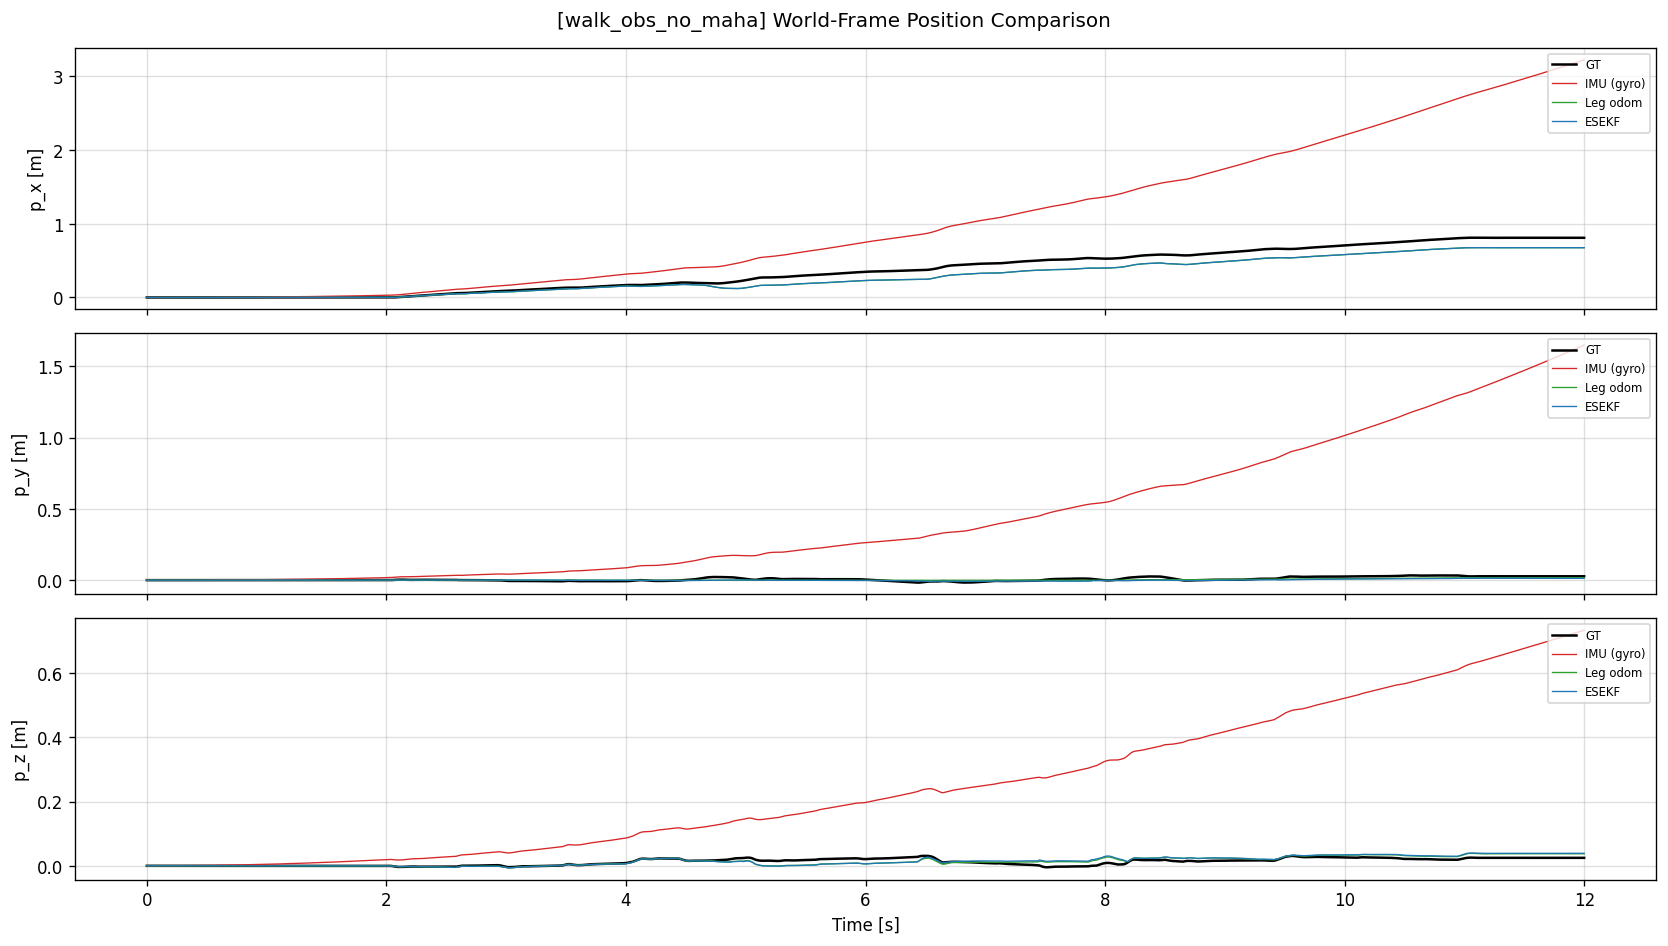

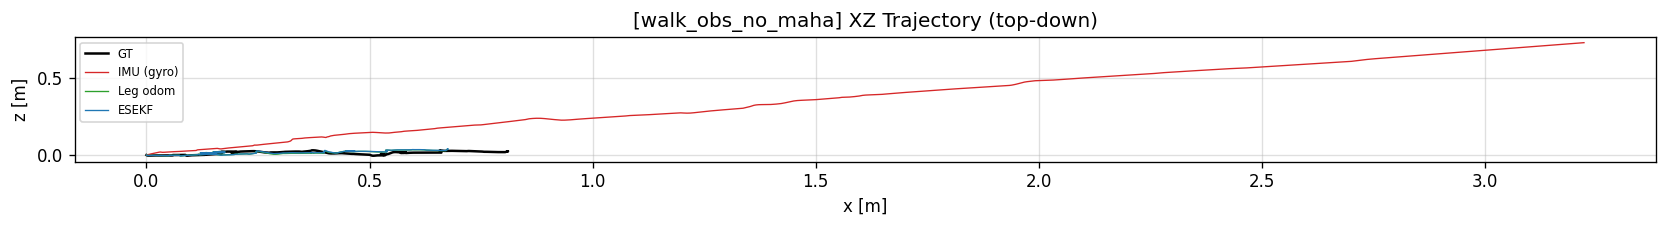


===== [walk_obs_no_maha] Velocity RMSE vs GT (mm/s) =====
Method                      Vx      Vy      Vz
IMU (gyro)               258.1   160.1    89.9
Leg odom                  47.6    41.8    27.2
ESEKF                     47.3    24.4    18.2

===== [walk_obs_no_maha] Position RMSE vs GT (mm) =====
Method                      Px      Py      Pz
IMU (gyro)               966.9   641.3   317.9
Leg odom                  96.7     9.4     8.6
ESEKF                     96.3    11.1     9.4


In [36]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

AXES   = ['x', 'y', 'z']
LABELS = {'gt': 'GT', 'imu': 'IMU (gyro)', 'leg': 'Leg odom', 'est': 'ESEKF'}
COLORS = {'gt': 'black', 'imu': 'tab:red', 'leg': 'tab:green', 'est': 'tab:blue'}

for name, D in datasets.items():
    t = D['t']

    # ── Velocity comparison ──────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'[{name}] Body-Frame Velocity Comparison')
    for i, ax_label in enumerate(AXES):
        ax = axes[i]
        ax.plot(t, D['gt_vel_b'][:, i],  lw=1.5, color=COLORS['gt'],  label=LABELS['gt'])
        ax.plot(t, D['imu_vel_b'][:, i], lw=0.8, color=COLORS['imu'], label=LABELS['imu'])
        ax.plot(t, D['leg_vel_b'][:, i], lw=0.8, color=COLORS['leg'], label=LABELS['leg'])
        ax.plot(t, D['est_vel_b'][:, i], lw=0.8, color=COLORS['est'], label=LABELS['est'])
        ax.set_ylabel(f'v_{ax_label} [m/s]')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.4)
    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    plt.show()

    # ── Position comparison ──────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'[{name}] World-Frame Position Comparison')
    for i, ax_label in enumerate(AXES):
        ax = axes[i]
        ax.plot(t, D['gt_pos'][:, i],  lw=1.5, color=COLORS['gt'],  label=LABELS['gt'])
        ax.plot(t, D['imu_pos'][:, i], lw=0.8, color=COLORS['imu'], label=LABELS['imu'])
        ax.plot(t, D['leg_pos'][:, i], lw=0.8, color=COLORS['leg'], label=LABELS['leg'])
        ax.plot(t, D['est_pos'][:, i], lw=0.8, color=COLORS['est'], label=LABELS['est'])
        ax.set_ylabel(f'p_{ax_label} [m]')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.4)
    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    plt.show()

    # ── XZ Trajectory (top-down) ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 2))
    ax.set_title(f'[{name}] XZ Trajectory (top-down)')
    ax.plot(D['gt_pos'][:, 0],  D['gt_pos'][:, 2],  lw=1.5, color=COLORS['gt'],  label=LABELS['gt'])
    ax.plot(D['imu_pos'][:, 0], D['imu_pos'][:, 2], lw=0.8, color=COLORS['imu'], label=LABELS['imu'])
    ax.plot(D['leg_pos'][:, 0], D['leg_pos'][:, 2], lw=0.8, color=COLORS['leg'], label=LABELS['leg'])
    ax.plot(D['est_pos'][:, 0], D['est_pos'][:, 2], lw=0.8, color=COLORS['est'], label=LABELS['est'])
    ax.set_xlabel('x [m]');  ax.set_ylabel('z [m]')
    ax.legend(fontsize=7);   ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ── RMSE tables ──────────────────────────────────────────────────────────
    methods = {
        'IMU (gyro)': (D['imu_vel_b'], D['imu_pos']),
        'Leg odom':   (D['leg_vel_b'], D['leg_pos']),
        'ESEKF':      (D['est_vel_b'], D['est_pos']),
    }
    print(f'\n===== [{name}] Velocity RMSE vs GT (mm/s) =====')
    print(f'{"Method":<22}{"Vx":>8}{"Vy":>8}{"Vz":>8}')
    for mname, (vel, _) in methods.items():
        err  = (vel - D['gt_vel_b']) * 1e3
        rmse = np.sqrt(np.mean(err**2, axis=0))
        print(f'{mname:<22}{rmse[0]:>8.1f}{rmse[1]:>8.1f}{rmse[2]:>8.1f}')

    print(f'\n===== [{name}] Position RMSE vs GT (mm) =====')
    print(f'{"Method":<22}{"Px":>8}{"Py":>8}{"Pz":>8}')
    for mname, (_, pos) in methods.items():
        err  = (pos - D['gt_pos']) * 1e3
        rmse = np.sqrt(np.mean(err**2, axis=0))
        print(f'{mname:<22}{rmse[0]:>8.1f}{rmse[1]:>8.1f}{rmse[2]:>8.1f}')

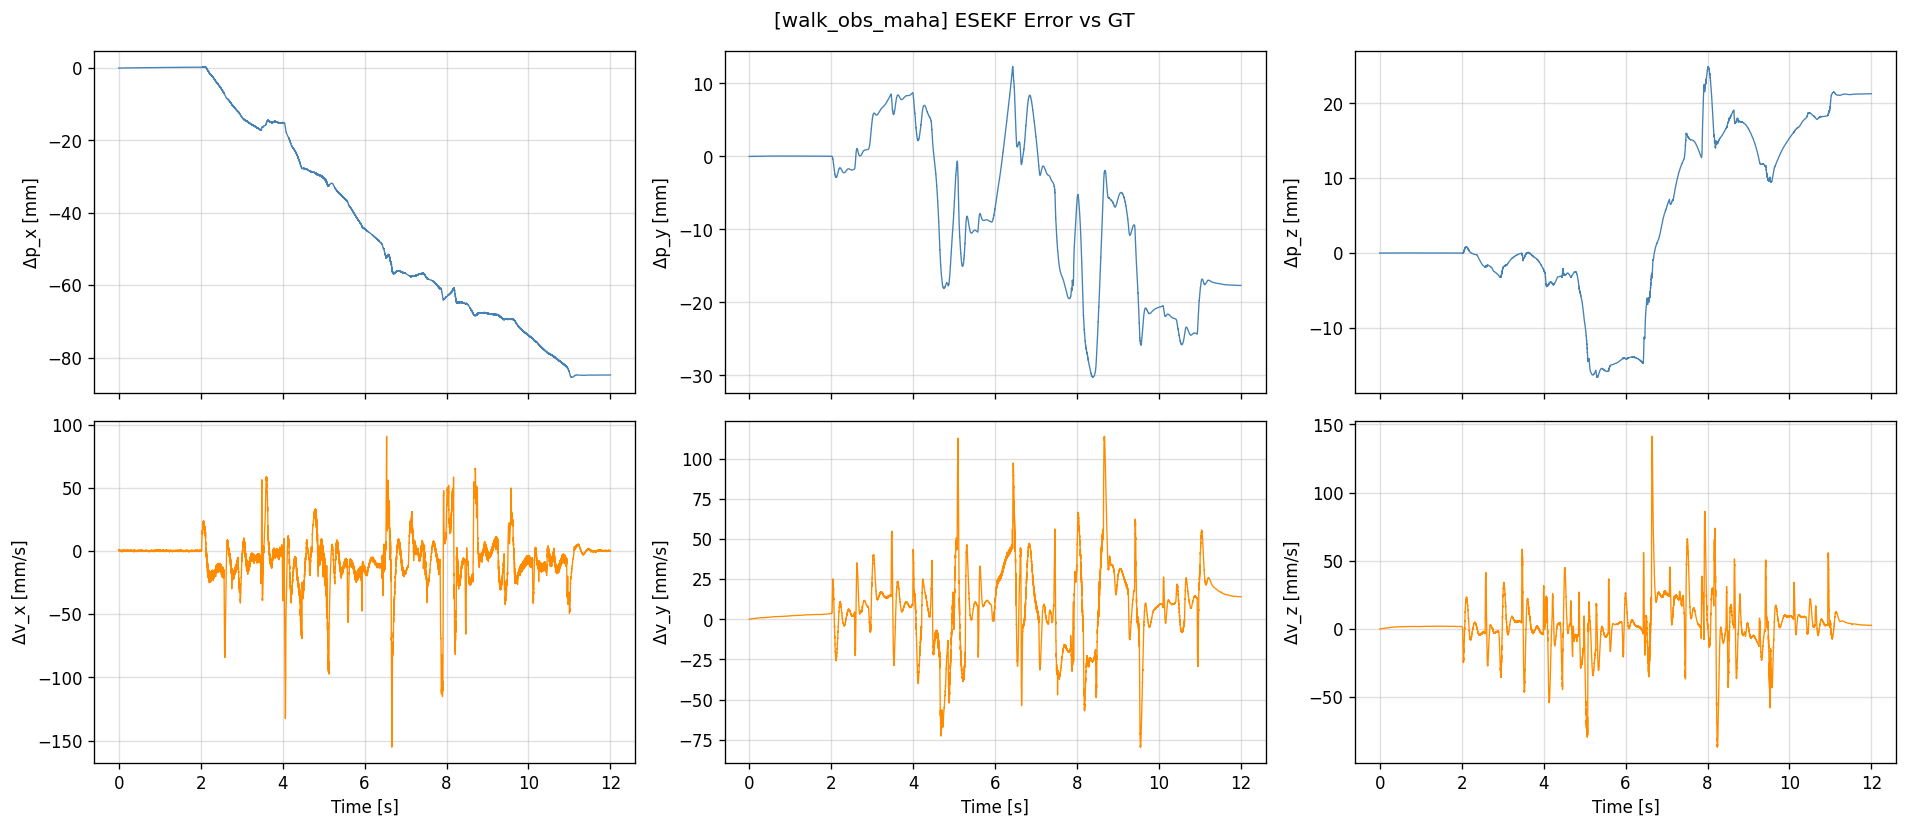

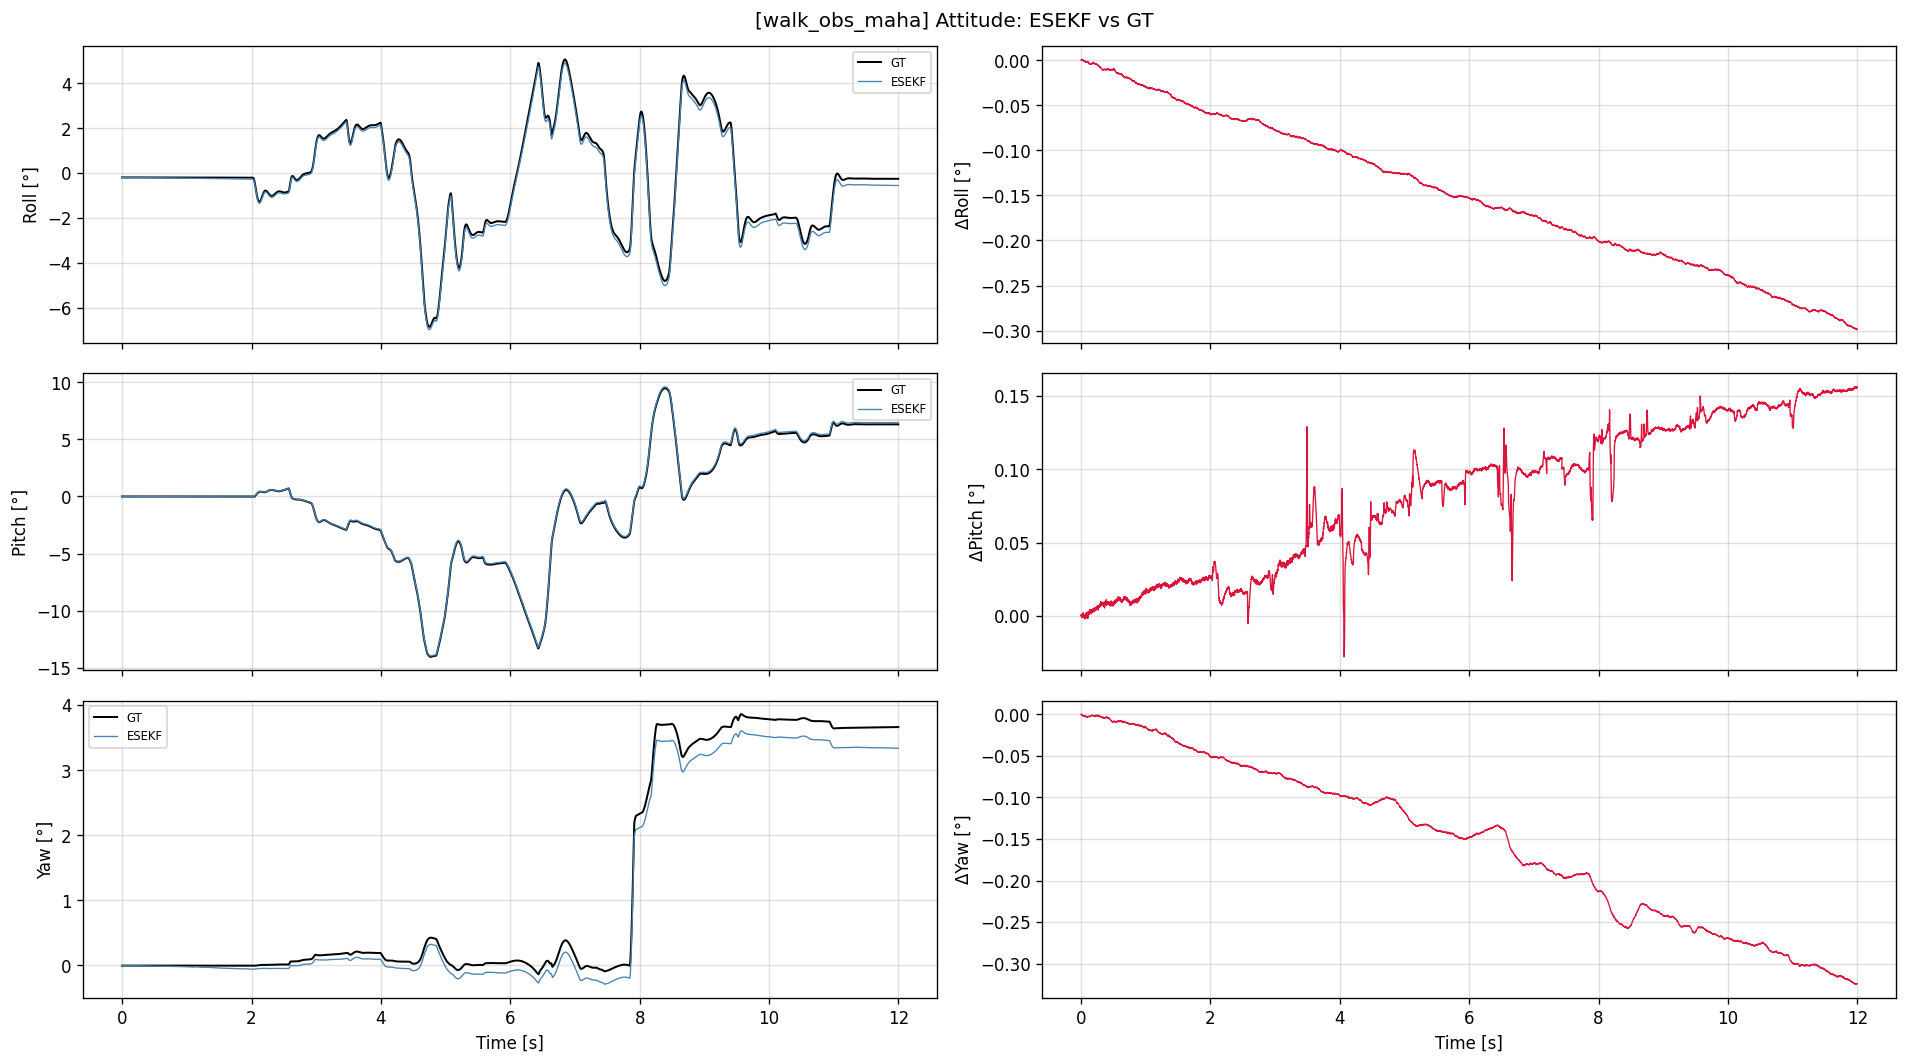

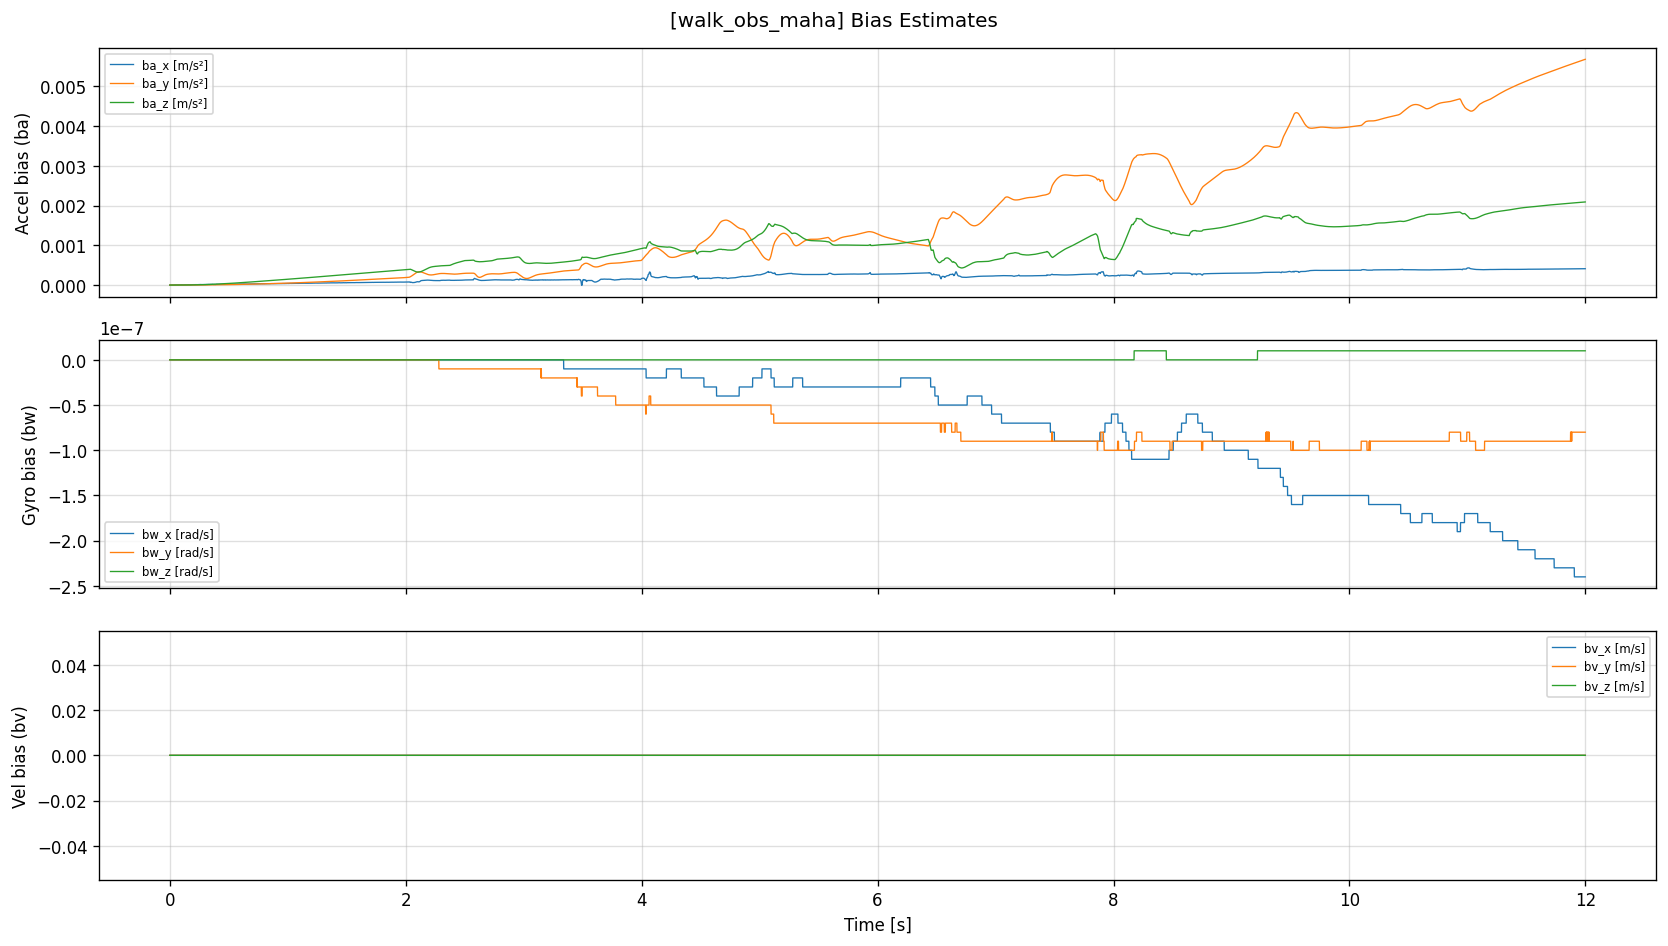

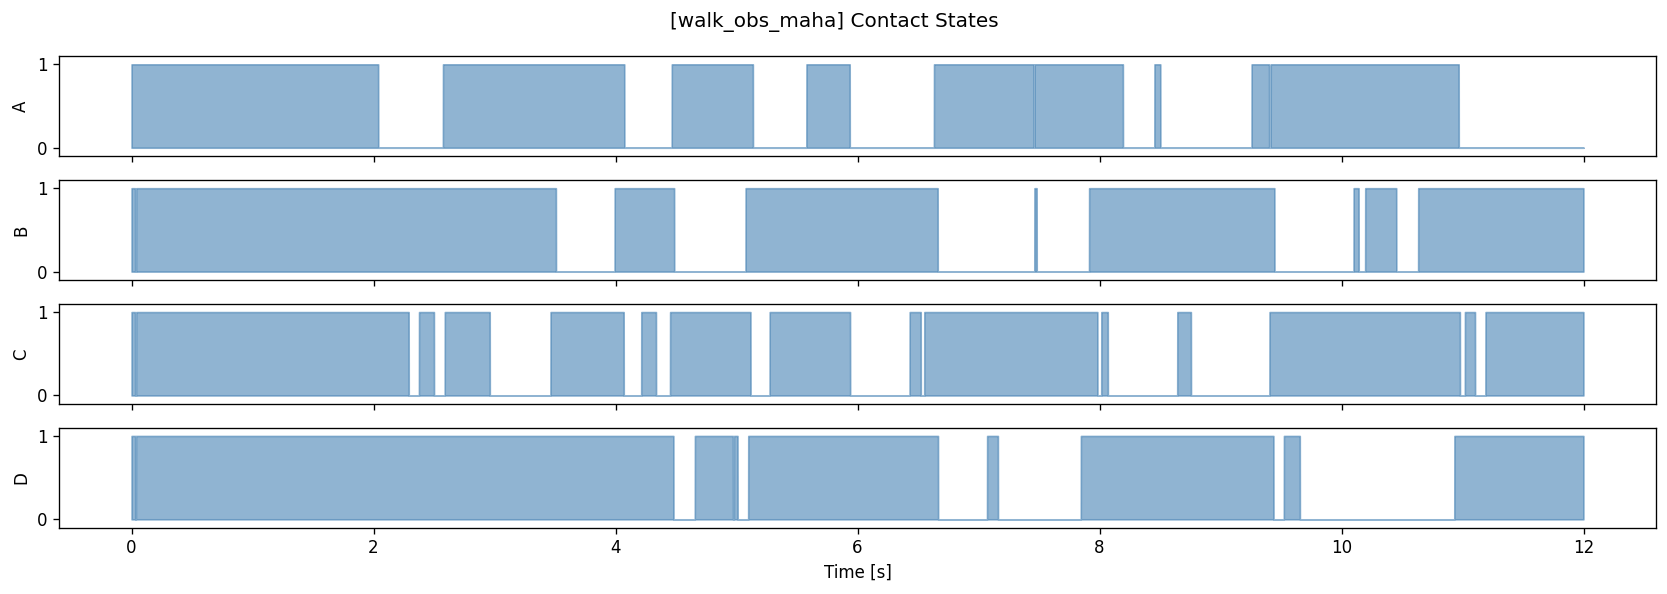

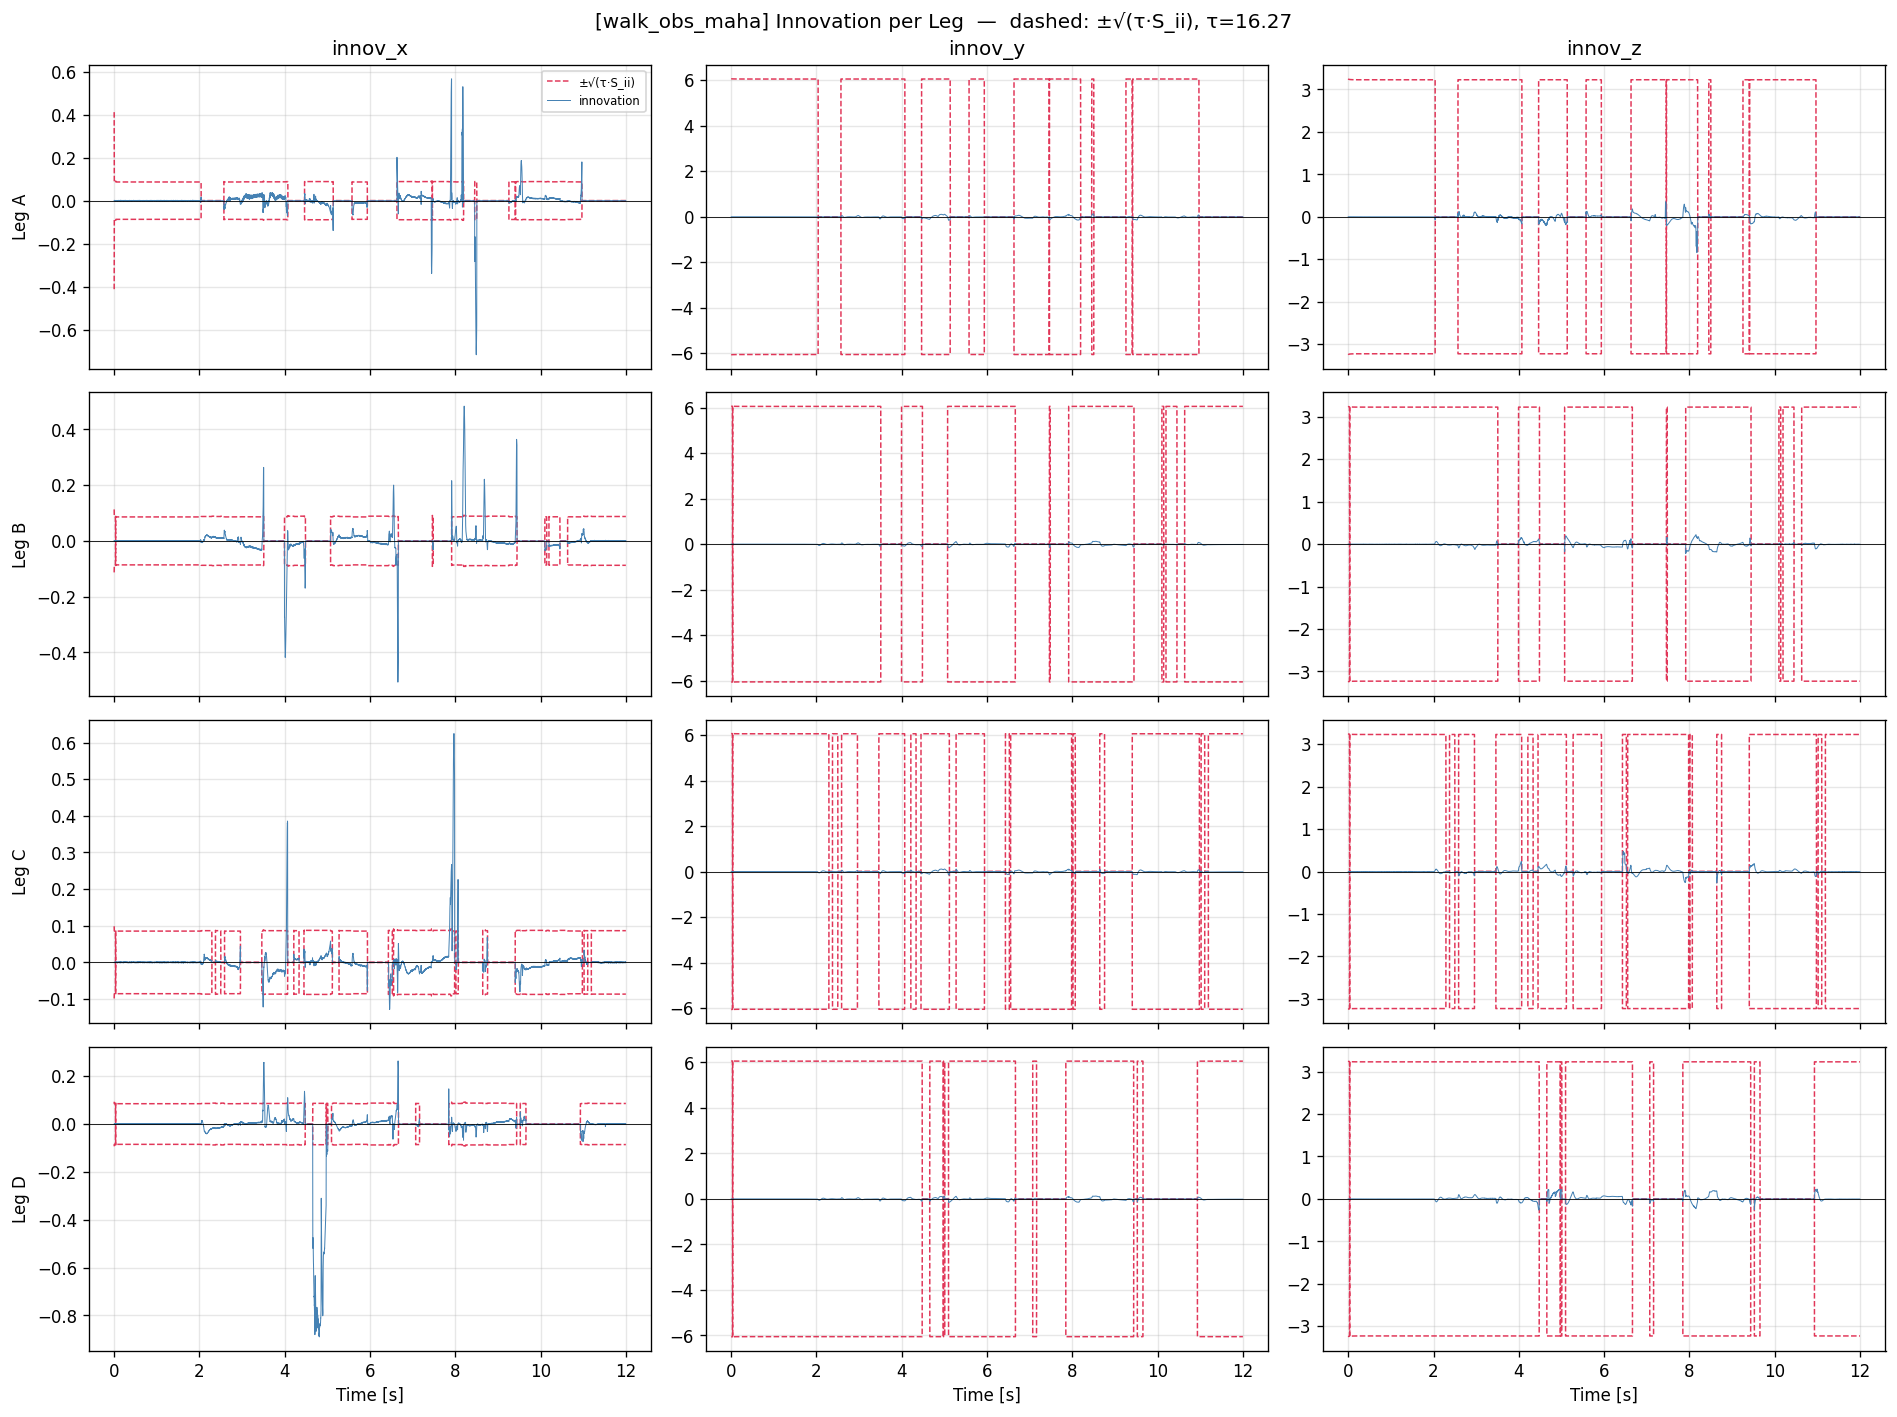

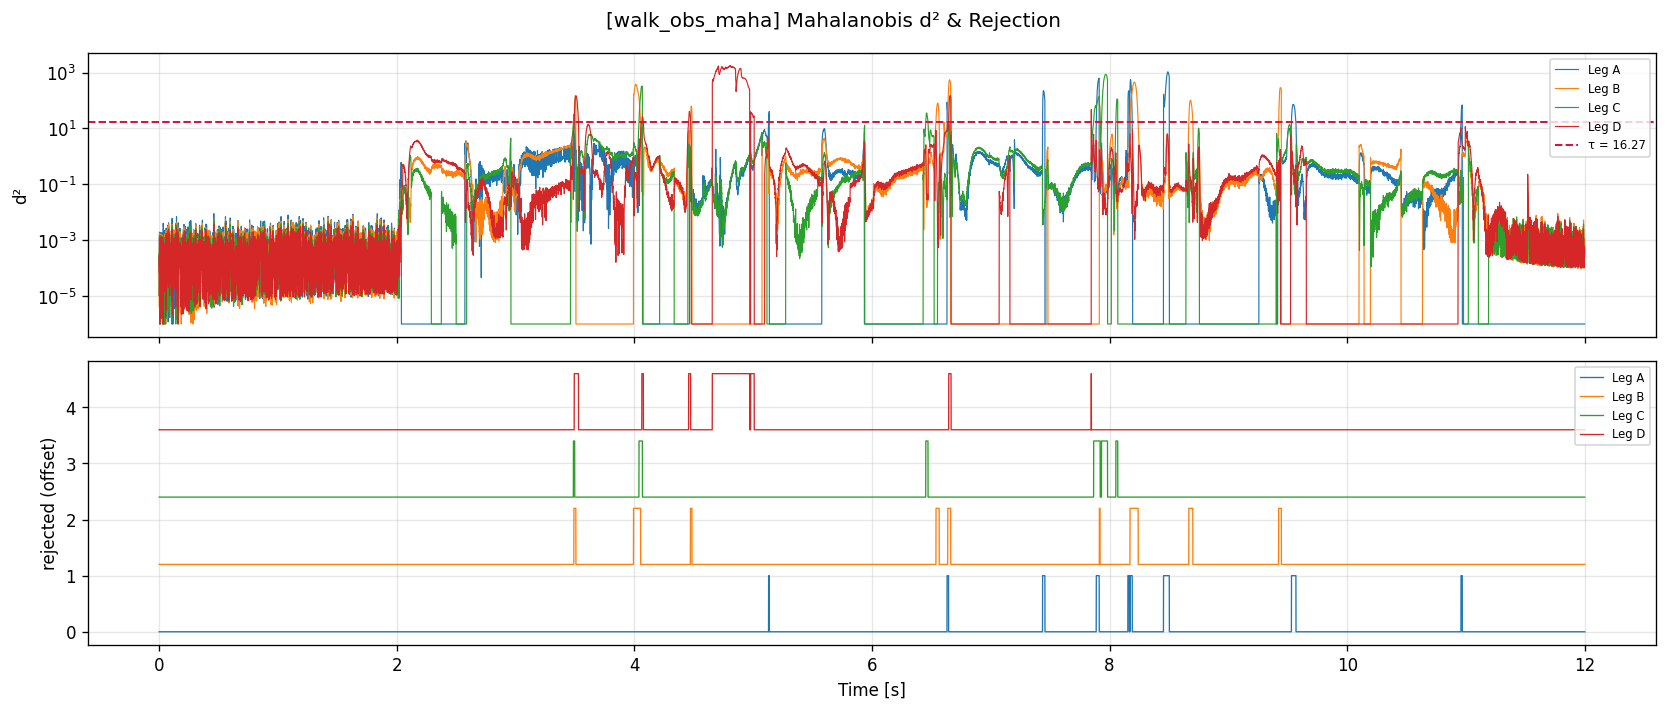

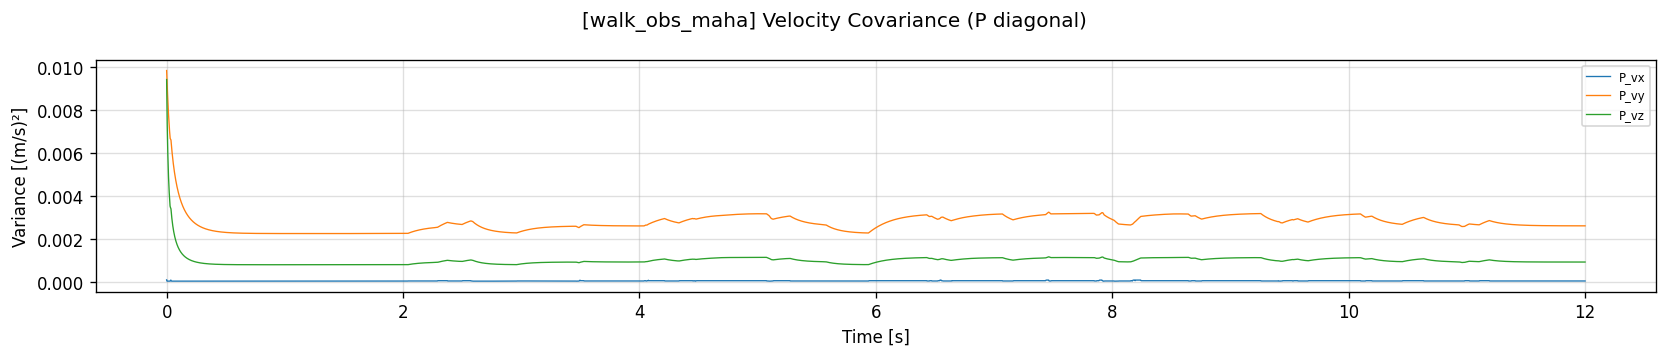

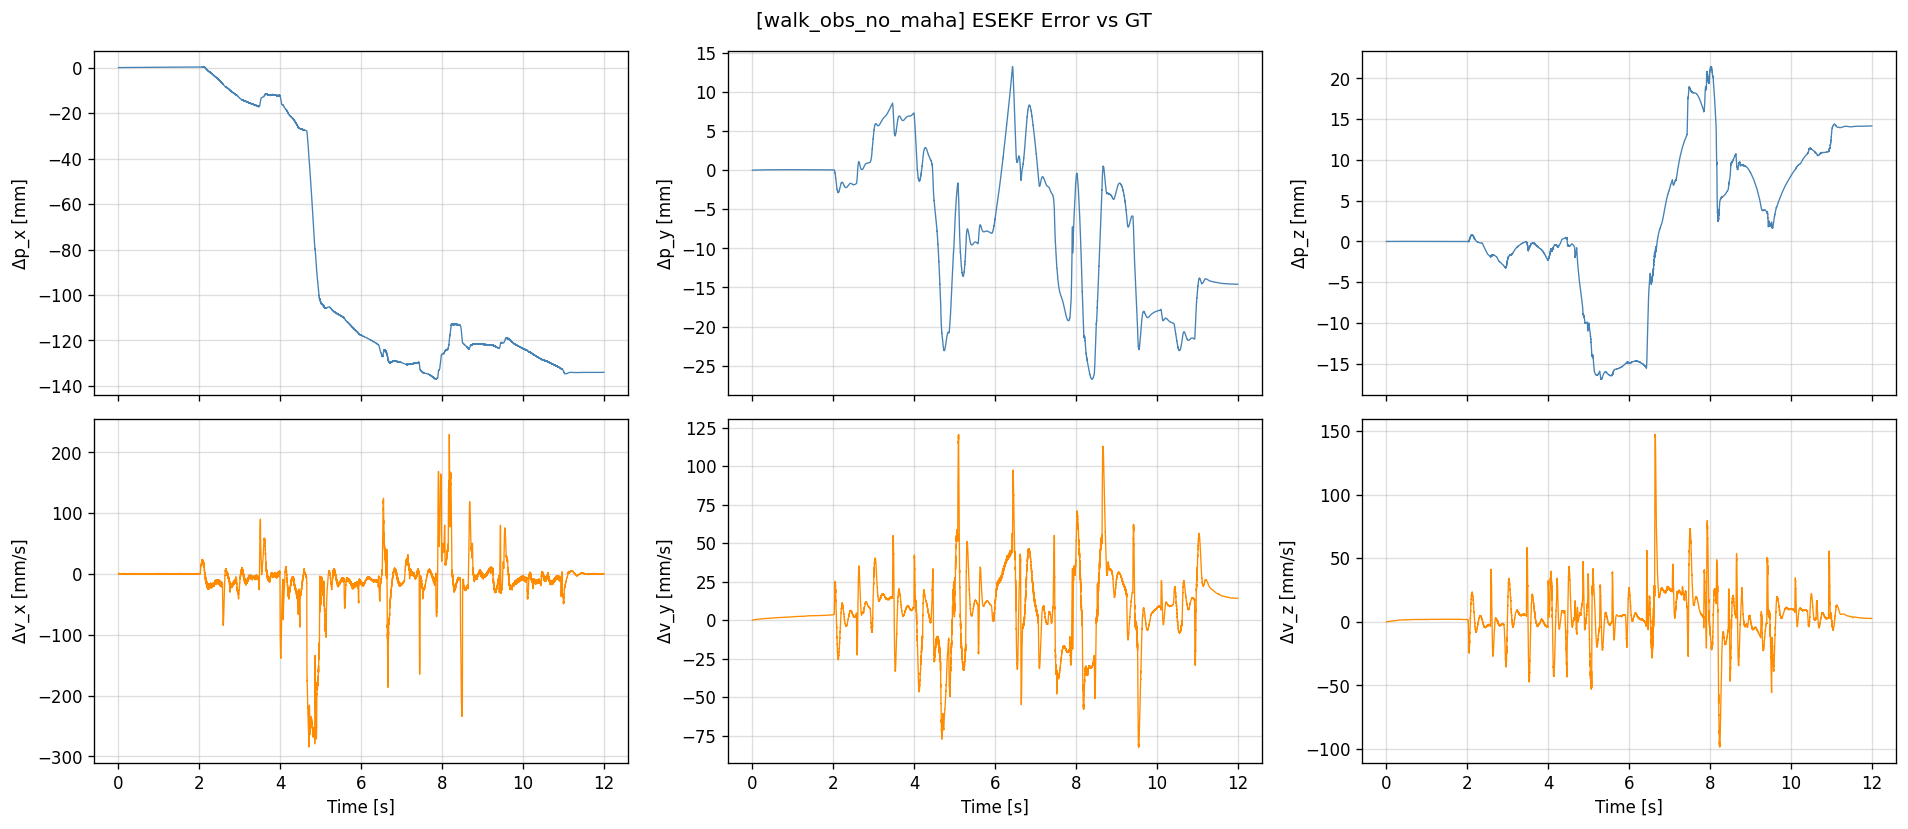

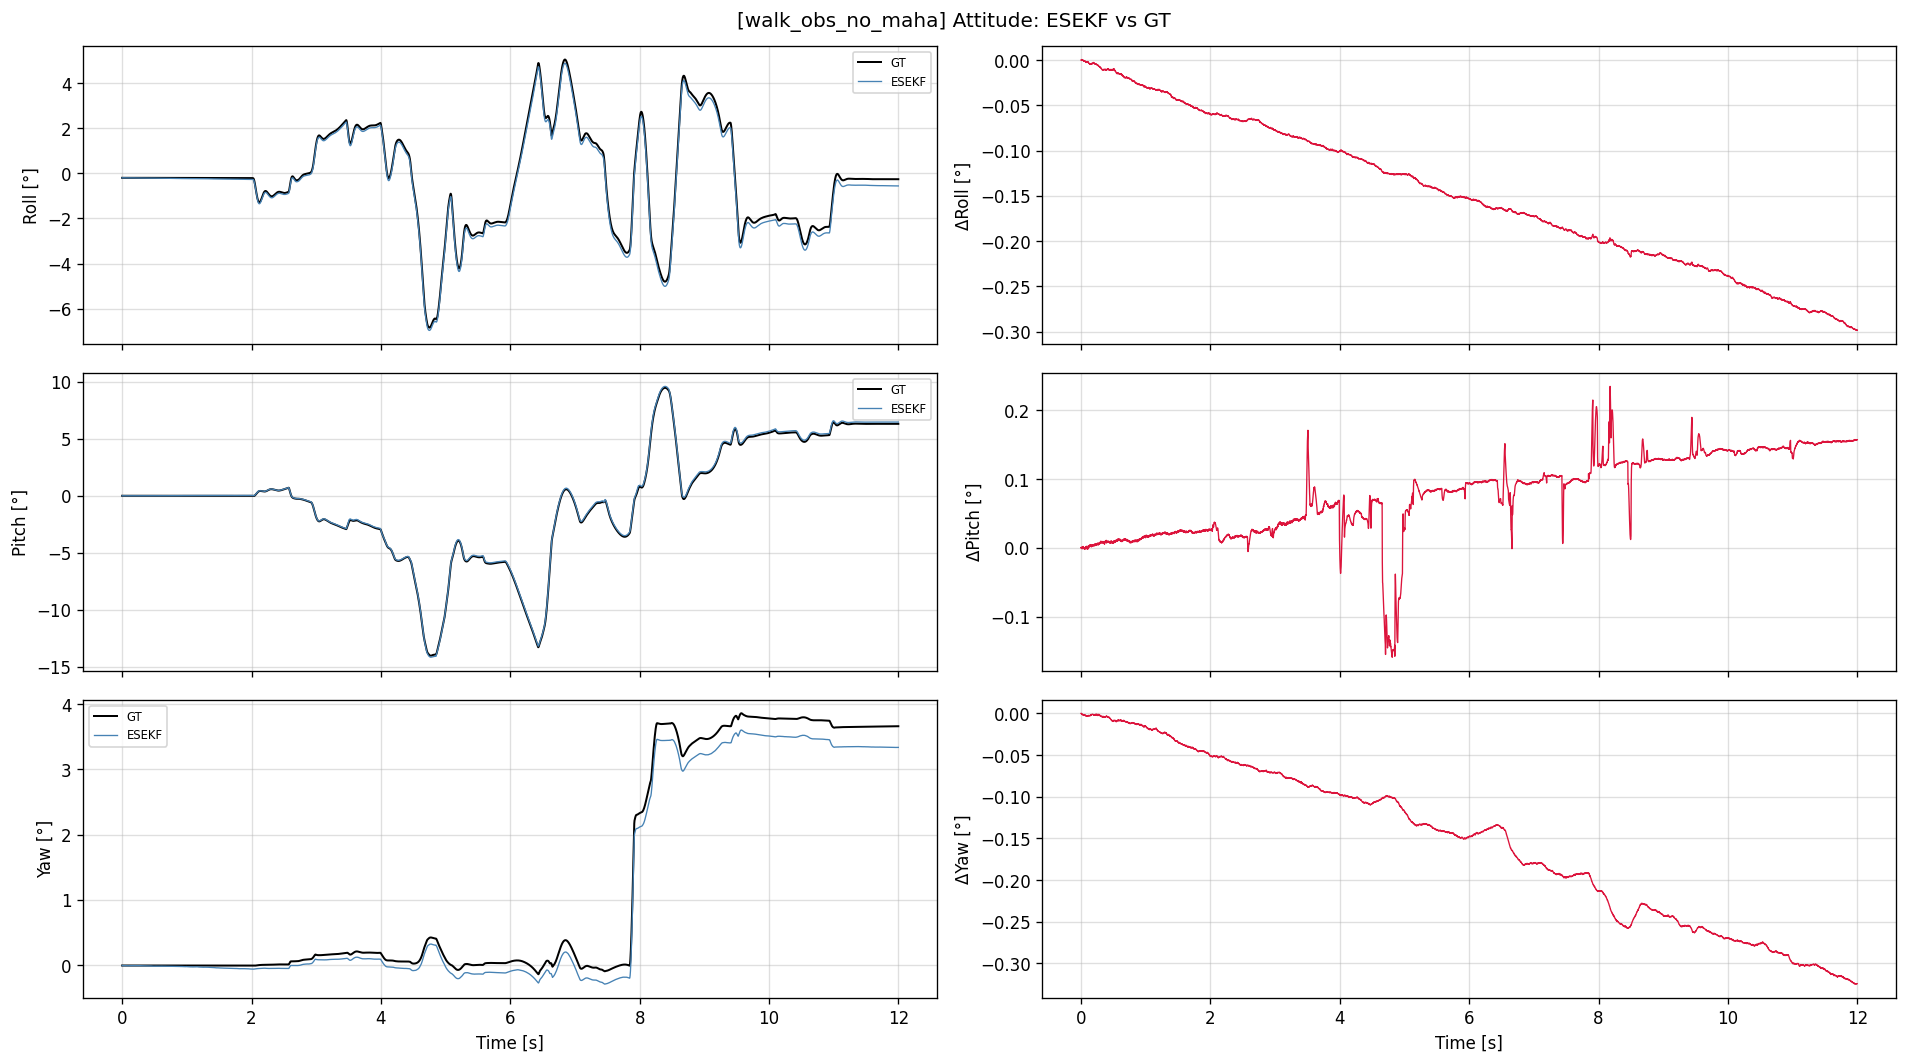

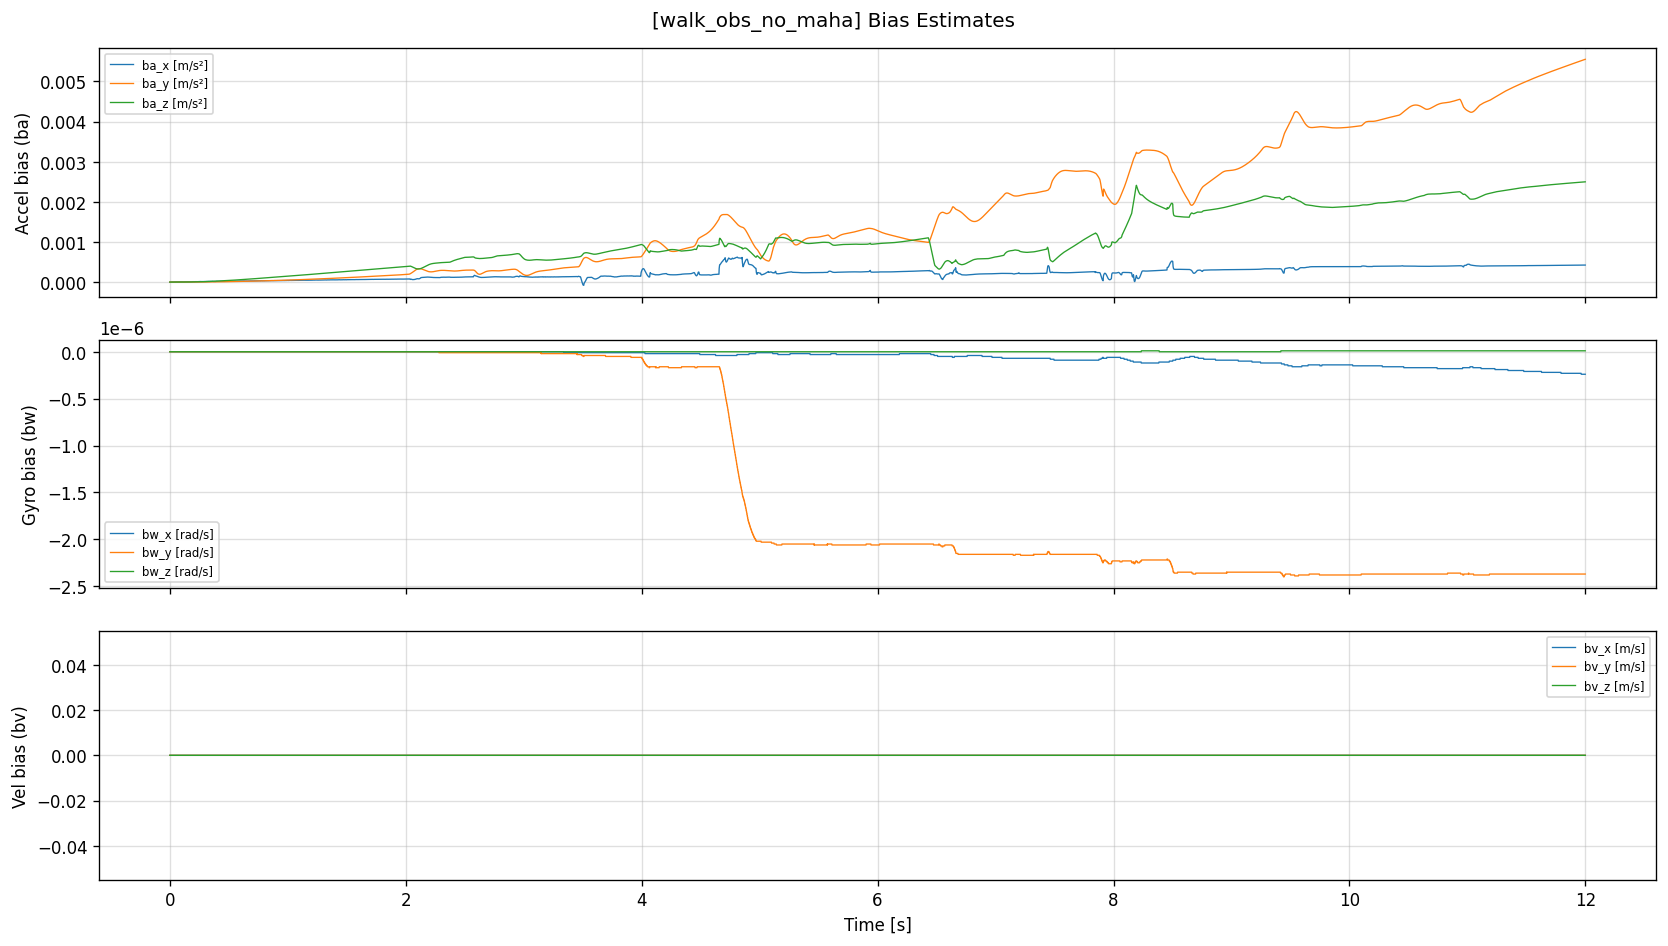

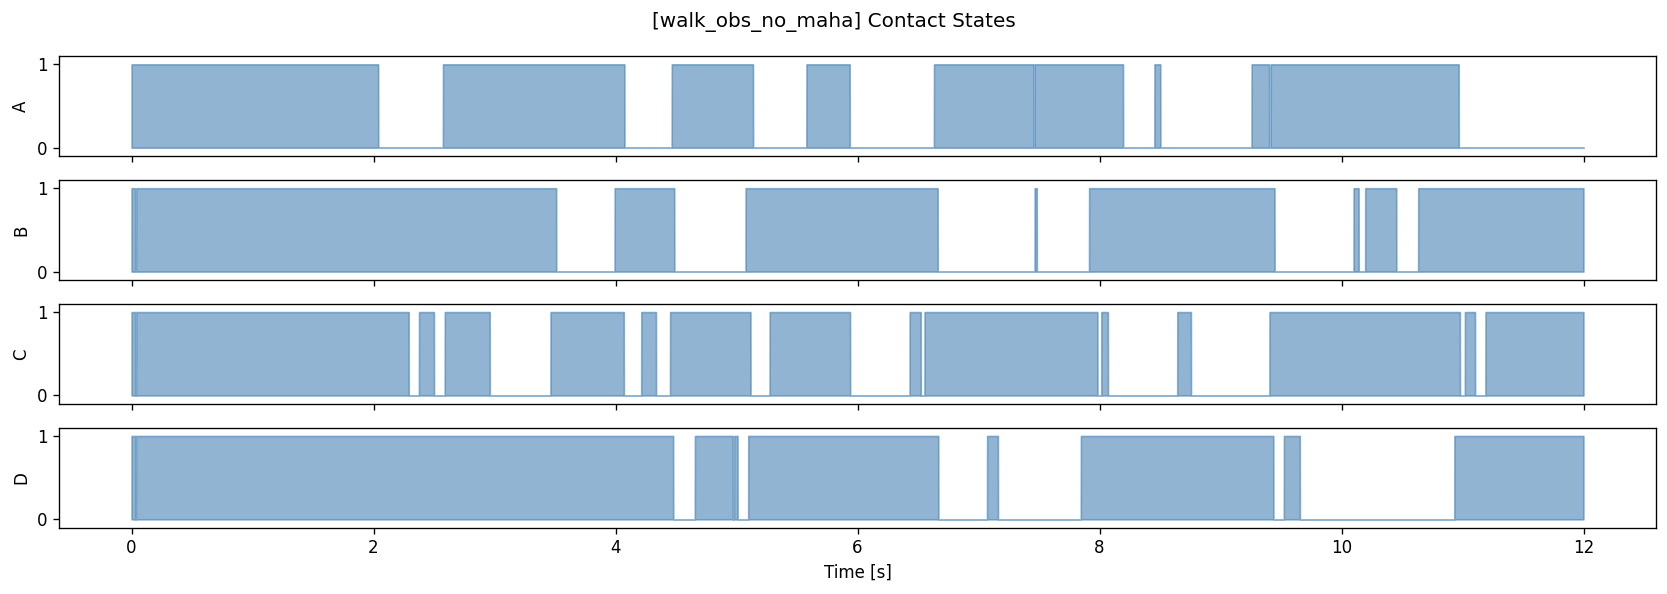

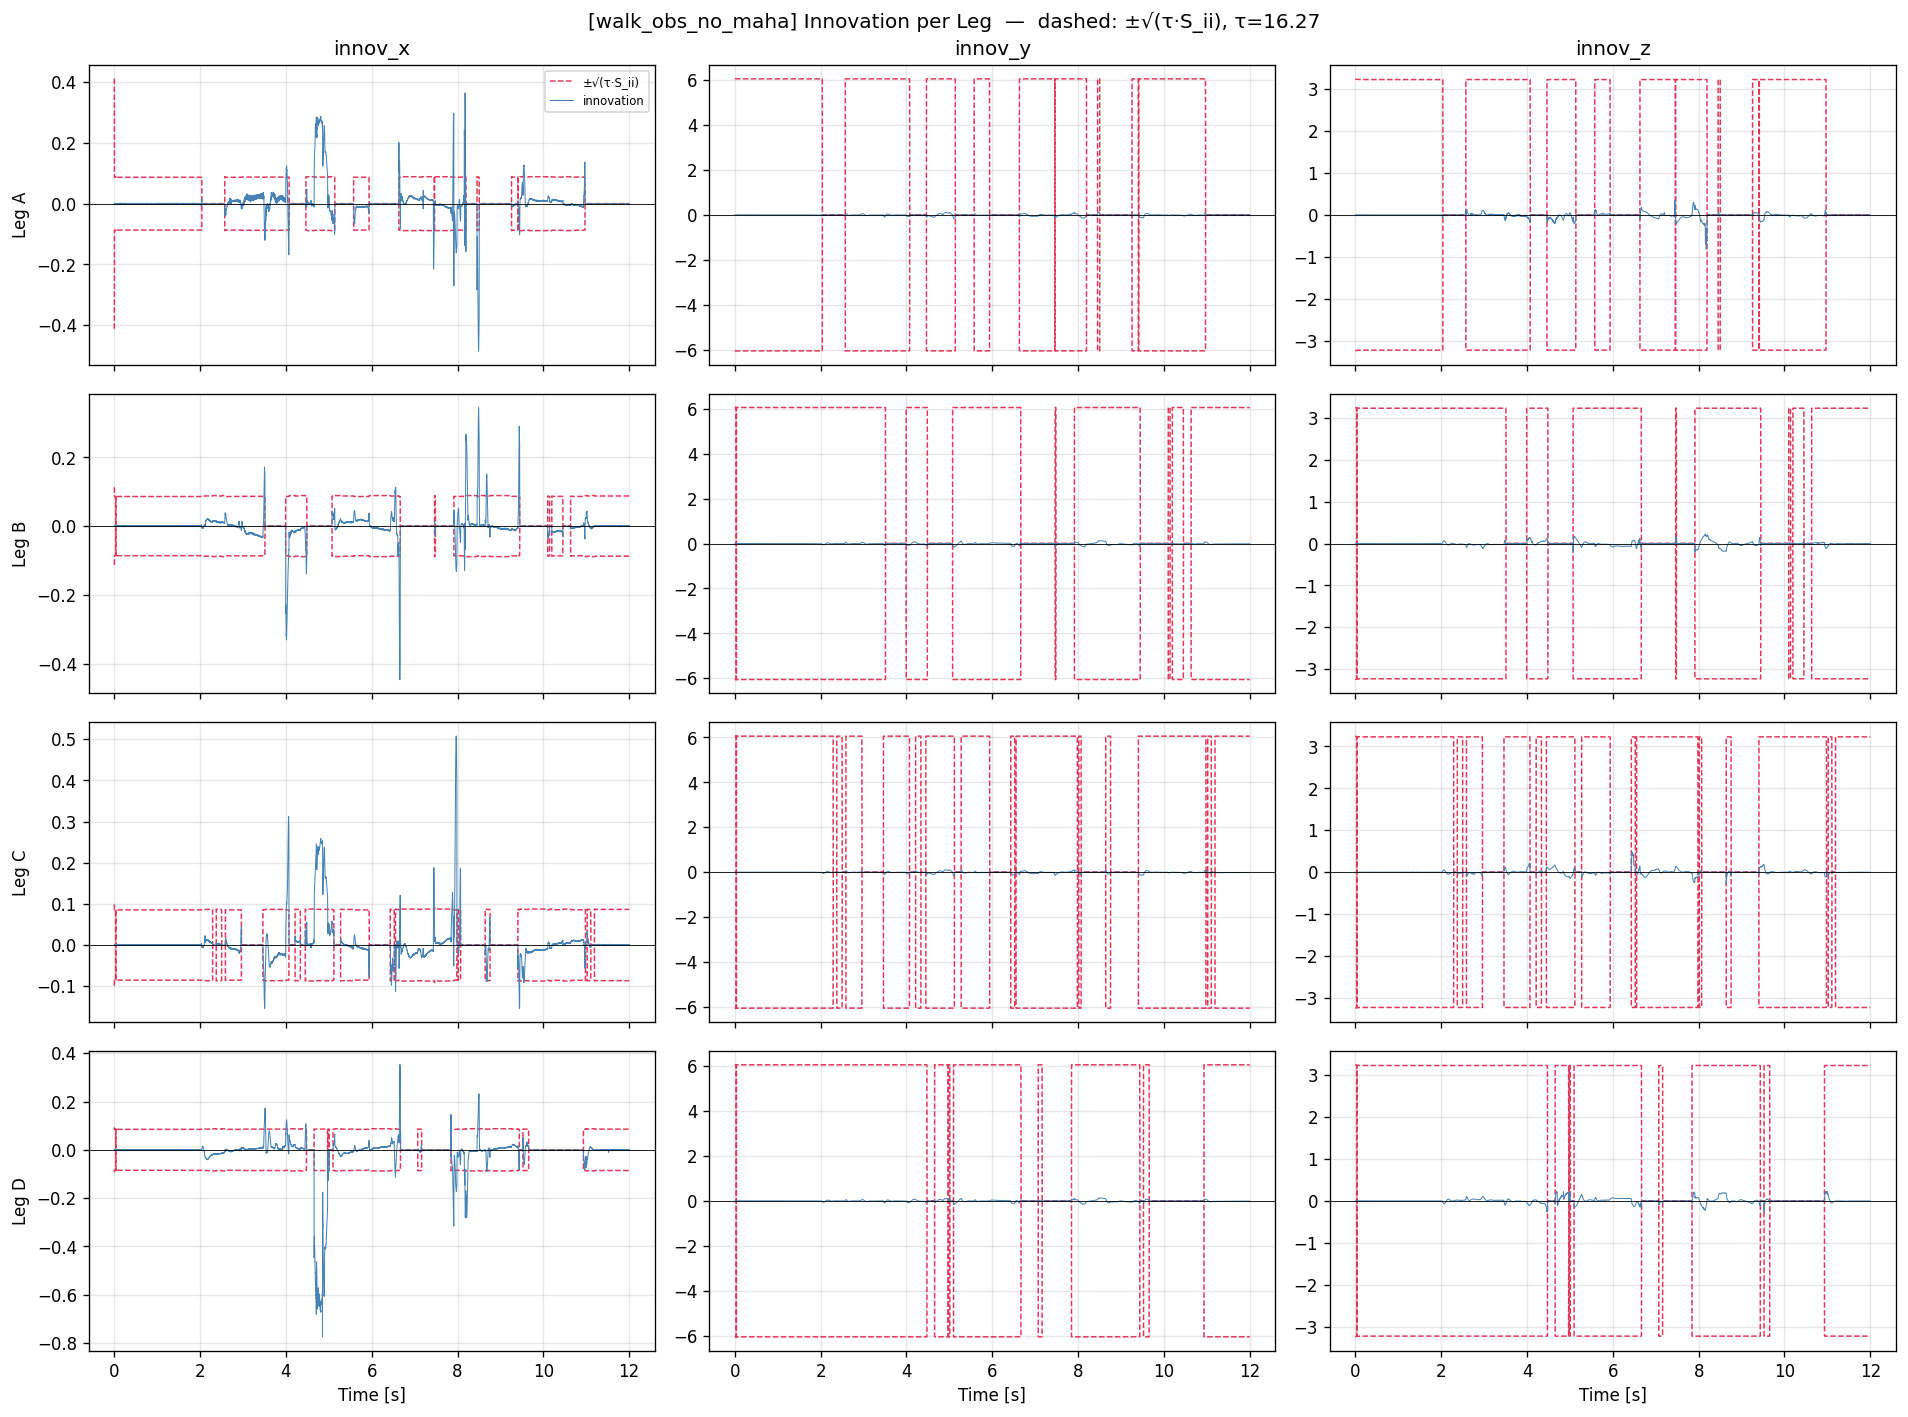

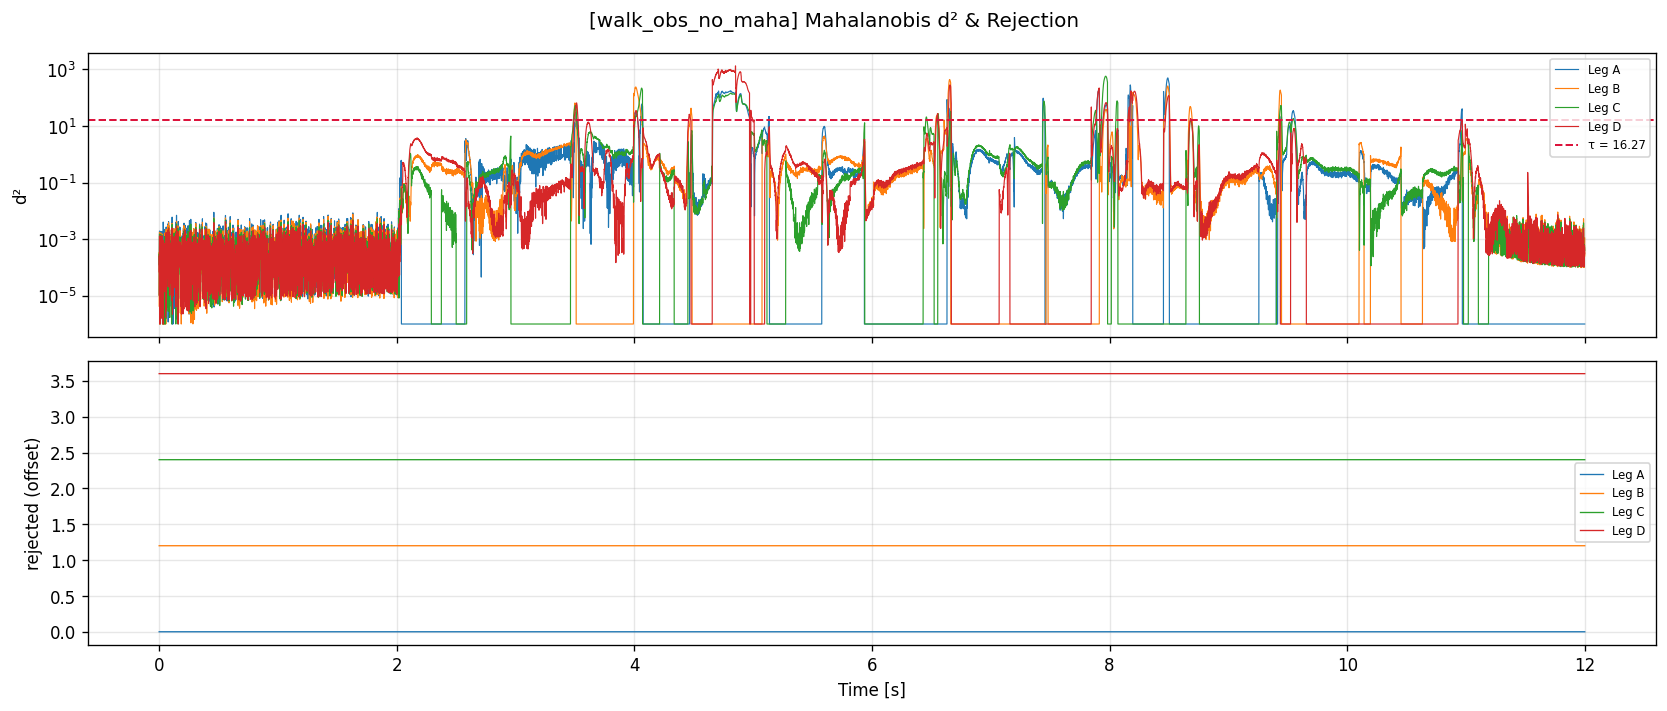

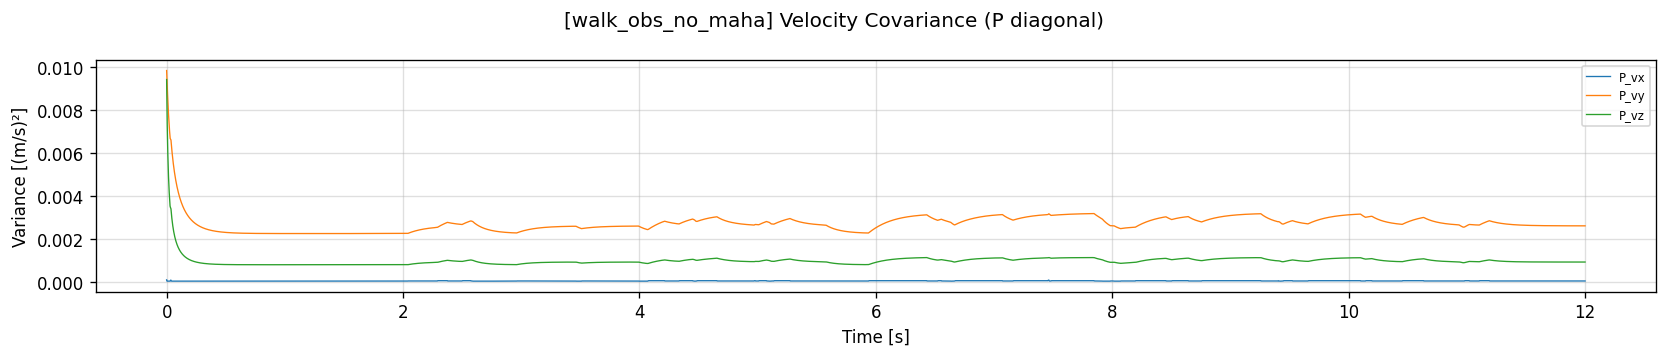

In [38]:
legs = ['a', 'b', 'c', 'd']

for name, D in datasets.items():
    t  = D['t']
    df = D['df']

    # ── Position & velocity error ─────────────────────────────────────────────
    pos_err = (D['est_pos']   - D['gt_pos'])   * 1e3   # mm
    vel_err = (D['est_vel_b'] - D['gt_vel_b']) * 1e3   # mm/s

    fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
    fig.suptitle(f'[{name}] ESEKF Error vs GT')
    for i, ax_label in enumerate(AXES):
        axes[0, i].plot(t, pos_err[:, i], lw=0.8, color='steelblue')
        axes[0, i].set_ylabel(f'Δp_{ax_label} [mm]');  axes[0, i].grid(True, alpha=0.4)
        axes[1, i].plot(t, vel_err[:, i], lw=0.8, color='darkorange')
        axes[1, i].set_ylabel(f'Δv_{ax_label} [mm/s]');  axes[1, i].grid(True, alpha=0.4)
        axes[1, i].set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Attitude ─────────────────────────────────────────────────────────────
    euler_gt  = quat_to_euler_xyz(df['gt_qw'].values,  df['gt_qx'].values,
                                   df['gt_qy'].values,  df['gt_qz'].values)
    euler_est = quat_to_euler_xyz(df['est_qw'].values, df['est_qx'].values,
                                   df['est_qy'].values, df['est_qz'].values)
    euler_labels = ['Roll', 'Pitch', 'Yaw']

    fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharex=True)
    fig.suptitle(f'[{name}] Attitude: ESEKF vs GT')
    for i, elabel in enumerate(euler_labels):
        axes[i, 0].plot(t, euler_gt[:, i],  lw=1.2, color='black',     label='GT')
        axes[i, 0].plot(t, euler_est[:, i], lw=0.8, color='steelblue', label='ESEKF')
        axes[i, 0].set_ylabel(f'{elabel} [°]')
        axes[i, 0].legend(fontsize=7);  axes[i, 0].grid(True, alpha=0.4)
        delta = euler_est[:, i] - euler_gt[:, i]
        axes[i, 1].plot(t, delta, lw=0.8, color='crimson')
        axes[i, 1].set_ylabel(f'Δ{elabel} [°]');  axes[i, 1].grid(True, alpha=0.4)
    axes[2, 0].set_xlabel('Time [s]');  axes[2, 1].set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Biases ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'[{name}] Bias Estimates')
    for ax_label in AXES:
        axes[0].plot(t, df[f'ba_{ax_label}'].values, lw=0.8, label=f'ba_{ax_label} [m/s²]')
    axes[0].set_ylabel('Accel bias (ba)');  axes[0].legend(fontsize=7);  axes[0].grid(True, alpha=0.4)
    for ax_label in AXES:
        axes[1].plot(t, df[f'bw_{ax_label}'].values, lw=0.8, label=f'bw_{ax_label} [rad/s]')
    axes[1].set_ylabel('Gyro bias (bw)');  axes[1].legend(fontsize=7);  axes[1].grid(True, alpha=0.4)
    for ax_label in AXES:
        axes[2].plot(t, df[f'bv_{ax_label}'].values, lw=0.8, label=f'bv_{ax_label} [m/s]')
    axes[2].set_ylabel('Vel bias (bv)');  axes[2].legend(fontsize=7);  axes[2].grid(True, alpha=0.4)
    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Contact states ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(14, 5), sharex=True)
    fig.suptitle(f'[{name}] Contact States')
    for i, leg in enumerate(legs):
        c = D['contacts'][:, i].astype(float)
        axes[i].fill_between(t, 0, c, alpha=0.6, color='steelblue')
        axes[i].set_ylim(-0.1, 1.1);  axes[i].set_ylabel(leg.upper())
        axes[i].set_yticks([0, 1]);   axes[i].grid(False)
    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Innovation ± Mahalanobis threshold ───────────────────────────────────
    # Per-axis threshold: |innov_i| = sqrt(τ · S_ii)  from D² = Σ innov²/S_ii ≤ τ
    inax  = ['x', 'y', 'z']
    s_col = {'x': 'S_xx', 'y': 'S_yy', 'z': 'S_zz'}
    fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True)
    fig.suptitle(f'[{name}] Innovation per Leg  —  dashed: ±√(τ·S_ii), τ={MAHA_THRESH}')
    for col_j, iax in enumerate(inax):
        axes[0, col_j].set_title(f'innov_{iax}')
    for row_i, leg in enumerate(legs):
        for col_j, iax in enumerate(inax):
            ax     = axes[row_i, col_j]
            innov  = df[f'innov_{iax}_{leg}'].values
            s_diag = df[f'{s_col[iax]}_{leg}'].values
            thresh = np.sqrt(MAHA_THRESH * np.abs(s_diag))
            lbl = '±√(τ·S_ii)' if (row_i == 0 and col_j == 0) else None
            ax.plot(t, +thresh, lw=0.9, color='crimson', ls='--', alpha=0.85, label=lbl)
            ax.plot(t, -thresh, lw=0.9, color='crimson', ls='--', alpha=0.85)
            ax.plot(t, innov,   lw=0.6, color='steelblue',
                    label='innovation' if (row_i == 0 and col_j == 0) else None)
            ax.axhline(0, color='k', lw=0.5)
            if col_j == 0:
                ax.set_ylabel(f'Leg {leg.upper()}')
            if row_i == 0 and col_j == 0:
                ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)
        if row_i == 3:
            for col_j in range(3):
                axes[row_i, col_j].set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Mahalanobis d² & rejection ────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f'[{name}] Mahalanobis d² & Rejection')
    ax1, ax2 = axes
    for leg in legs:
        d2 = df[f'd2_{leg}'].values.clip(1e-6)
        ax1.plot(t, d2, lw=0.7, label=f'Leg {leg.upper()}')
    ax1.axhline(MAHA_THRESH, color='crimson', ls='--', lw=1.2,
                label=f'τ = {MAHA_THRESH}')
    ax1.set_yscale('log');  ax1.set_ylabel('d²')
    ax1.legend(fontsize=7);  ax1.grid(True, alpha=0.3, which='both')
    for i, leg in enumerate(legs):
        rej = df[f'rejected_{leg}'].values.astype(float)
        ax2.plot(t, rej + i * 1.2, lw=0.8, label=f'Leg {leg.upper()}')
    ax2.set_ylabel('rejected (offset)');  ax2.legend(fontsize=7);  ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Velocity covariance ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 3))
    fig.suptitle(f'[{name}] Velocity Covariance (P diagonal)')
    for ax_label in AXES:
        ax.plot(t, df[f'P_v{ax_label}'].values, lw=0.8, label=f'P_v{ax_label}')
    ax.set_ylabel('Variance [(m/s)²]');  ax.set_xlabel('Time [s]')
    ax.legend(fontsize=7);  ax.grid(True, alpha=0.4)
    plt.tight_layout();  plt.show()

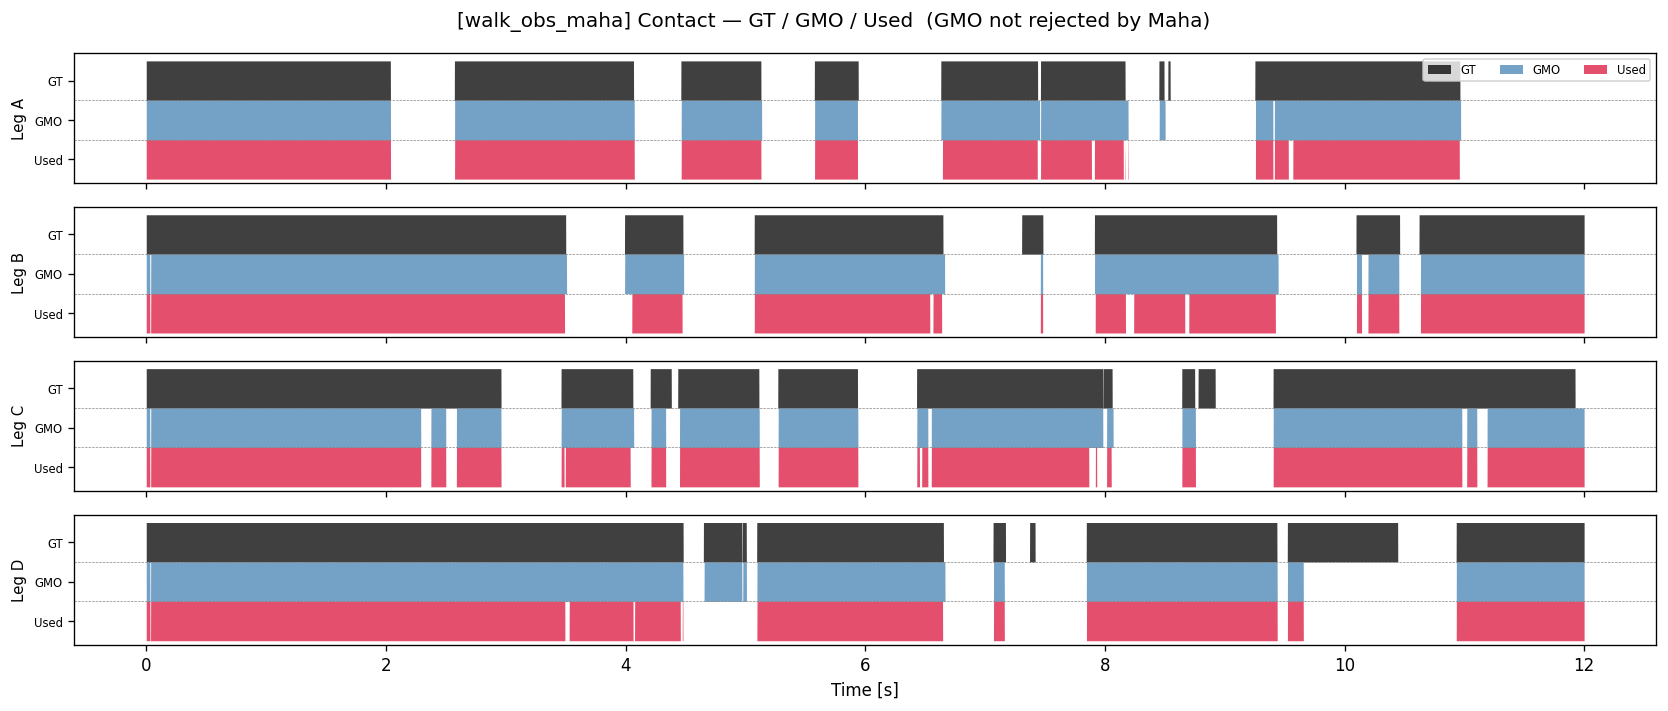

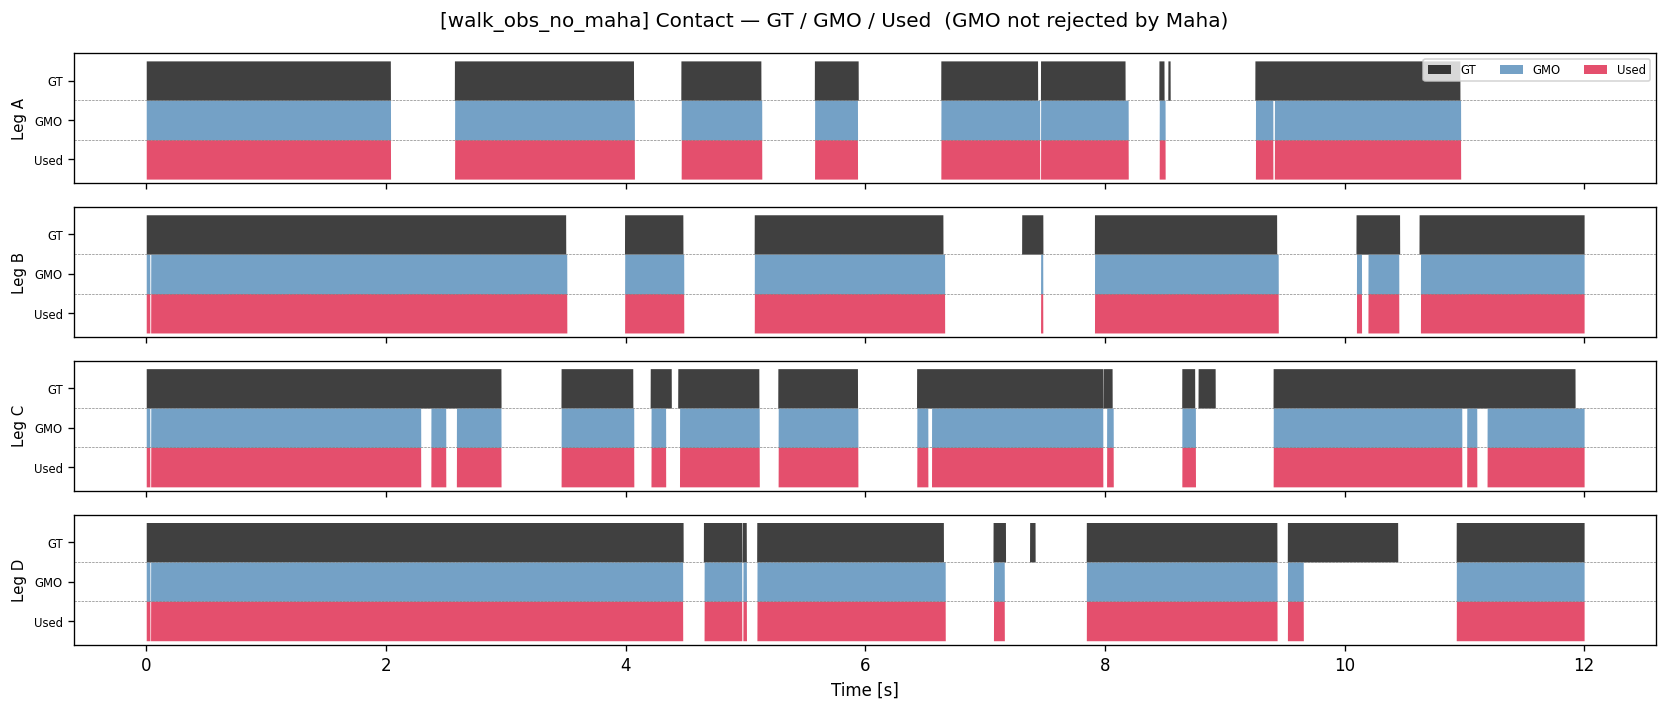

In [40]:
import re

for name, D in datasets.items():
    t   = D['t']
    df  = D['df']
    N   = len(t)

    # ── Load GT contact CSV ─────────────────────────────────────────────────
    # Derive GT csv: strip _maha / _no_maha suffix  (e.g. walk_obs_maha → walk_obs.csv)
    base    = re.sub(r'_(no_maha|maha)$', '', name)
    gt_path = OUTPUT_DIR / f'{base}.csv'
    if not gt_path.exists():
        print(f'[{name}] GT CSV not found: {gt_path}  — skipping')
        continue
    df_gt = pd.read_csv(gt_path).iloc[:N].reset_index(drop=True)

    # Per-leg GT contact  (sim_contact_state_a/b/c/d)
    gt_c = np.column_stack([df_gt[f'sim_contact_state_{leg}'].values
                             for leg in legs]).astype(float)   # (N, 4)

    # GMO contact  (contact_a/b/c/d  from ESEKF csv)
    gmo_c = D['contacts'].astype(float)                        # (N, 4)

    # Used = GMO in contact AND not rejected by Mahalanobis
    rej    = np.column_stack([df[f'rejected_{leg}'].values
                               for leg in legs]).astype(bool)
    used_c = (gmo_c.astype(bool) & ~rej).astype(float)        # (N, 4)

    # ── Plot ────────────────────────────────────────────────────────────────
    LEG_LABELS = ['A', 'B', 'C', 'D']
    C = {'gt': 'black', 'gmo': 'steelblue', 'used': 'crimson'}

    fig, axes = plt.subplots(4, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f'[{name}] Contact — GT / GMO / Used  (GMO not rejected by Maha)')

    for i, (ax, lbl) in enumerate(zip(axes, LEG_LABELS)):
        kw = dict(alpha=0.75, lw=0)
        ax.fill_between(t, 2.0, 2.0 + gt_c[:, i],   **kw, color=C['gt'],
                        label='GT'   if i == 0 else None)
        ax.fill_between(t, 1.0, 1.0 + gmo_c[:, i],  **kw, color=C['gmo'],
                        label='GMO'  if i == 0 else None)
        ax.fill_between(t, 0.0, 0.0 + used_c[:, i], **kw, color=C['used'],
                        label='Used' if i == 0 else None)
        ax.set_ylim(-0.1, 3.2)
        ax.set_yticks([0.5, 1.5, 2.5])
        ax.set_yticklabels(['Used', 'GMO', 'GT'], fontsize=7)
        ax.set_ylabel(f'Leg {lbl}', fontsize=9)
        ax.axhline(1.0, color='gray', lw=0.4, ls='--')
        ax.axhline(2.0, color='gray', lw=0.4, ls='--')
        ax.grid(False)
        if i == 0:
            ax.legend(loc='upper right', fontsize=7, ncol=3)

    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    plt.show()


# ESEKF Analysis — Reference Guide

## CSV Column Reference (82 total: Index + 81 data)

| # | Column | Description |
|---|--------|-------------|
| 1 | `Index` | Step counter (0-based); time = Index × 0.001 s |
| 2–4 | `sim_pos_x/y/z` | GT (simulator) position [m], world frame |
| 5–7 | `est_pos_x/y/z` | ESEKF estimated position [m], world frame |
| 8–10 | `est_vel_x/y/z` | ESEKF estimated velocity [m/s], body frame |
| 11–14 | `contact_a/b/c/d` | Per-leg contact state (0/1) |
| 15–17 | `z_avg_x/y/z` | Leg odometry measurement (z_avg) [m/s], body frame |
| 18–20 | `ba_x/y/z` | Accelerometer bias estimate [m/s²] |
| 21–23 | `bw_x/y/z` | Gyroscope bias estimate [rad/s] |
| 24–26 | `bv_x/y/z` | Velocity bias estimate [m/s] |
| 27–30 | `est_qw/qx/qy/qz` | ESEKF estimated quaternion |
| 31–34 | `gt_qw/qx/qy/qz` | GT quaternion |
| 35–38 | `d2_a/b/c/d` | Mahalanobis distance² per leg |
| 39–42 | `rejected_a/b/c/d` | Measurement rejection flag per leg |
| 43–54 | `innov_{x,y,z}_{a,b,c,d}` | Innovation vector per leg (3×4=12) |
| 55–66 | `S_{xx,yy,zz}_{a,b,c,d}` | Innovation covariance diagonal per leg (3×4=12) |
| 67–69 | `P_vx/vy/vz` | Velocity covariance diagonal [(m/s)²] |
| 70–72 | `pred_vel_x/y/z` | Predicted (pre-update) velocity [m/s] |
| 73–75 | `imu_gyro_pos_x/y/z` | IMU gyro-integrated position [m] |
| 76–78 | `imu_gyro_vel_bx/by/bz` | IMU gyro-integrated velocity [m/s], body frame |
| 79–82 | `imu_gyro_qw/qx/qy/qz` | IMU gyro-integrated quaternion |

## Data Pipeline

```
GT velocity (world):  central_diff(sim_pos, dt=0.001)  →  IIR LPF @ 10 Hz
GT velocity (body):   R_gt^T  @  gt_vel_w
IMU velocity (body):  directly from imu_gyro_vel_b* cols (gyro-integrated)
Leg velocity (body):  z_avg_* cols
Leg position:         cumsum(R_est @ z_avg * dt)
ESEKF velocity:       est_vel_* cols (body frame)
ESEKF position:       est_pos_* cols (world frame, origin-zeroed)
```

## Notes
- **No scipy**: System scipy has numpy binary incompatibility → pure numpy only
- **Quaternion convention**: `qw` scalar-first
- **Euler angles**: XYZ extrinsic (= ZYX intrinsic), degrees
- **mahalanobis_threshold**: χ²(3, p=0.999) = 16.27 (default)